# Phys 235 Schwinger VQS Main Skeleton

Project entry point. Concrete parameters, fixture I/O, workflow ordering, validation display, and report-ready plots live here; algorithm code lives in numbered `.py` modules.


## 1. Dependencies and Local Imports


In [14]:
# Uncomment in Colab if needed.
# %pip install -q pennylane scipy matplotlib

from pathlib import Path
import importlib
import json
import sys

import numpy as onp
import matplotlib.pyplot as plt

PLOT_DPI = 400
PLOT_SINGLE_FIGSIZE = (7.2, 4.6)
PLOT_TWO_PANEL_FIGSIZE = (11.6, 4.6)
plt.rcParams.update({
    "figure.dpi": PLOT_DPI,
    "savefig.dpi": PLOT_DPI,
    "figure.figsize": PLOT_SINGLE_FIGSIZE,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.8,
    "savefig.bbox": "tight",
})

PATH_CANDIDATES = (
    (Path("."), Path("..")),
    (Path("code"), Path(".")),
    (Path("235_Final_Project") / "code", Path("235_Final_Project")),
)
for code_dir, project_root in PATH_CANDIDATES:
    if (code_dir / "module1_vqe.py").exists():
        CODE_DIR = code_dir
        PROJECT_ROOT = project_root
        break
else:
    raise FileNotFoundError("Could not find code/module1_vqe.py from the current notebook directory.")

TEST_DATA_ROOT = PROJECT_ROOT / "test_data"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

def display_path(path):
    return Path(path).as_posix()


import schwinger_core as core_lib
import module1_vqe as module1_lib
import module2_quench as module2_lib
import module3_trotter as module3_lib
import module4_mclachlan_vqs as module4_lib
core_lib = importlib.reload(core_lib)
module1_lib = importlib.reload(module1_lib)
module2_lib = importlib.reload(module2_lib)
module3_lib = importlib.reload(module3_lib)
module4_lib = importlib.reload(module4_lib)

from schwinger_core import compute_observables, exact_time_evolution, state_fidelity
from module1_vqe import Module1Config, module1_acceptance_passed, run_module1_from_config, run_vqe, run_vqe_restart_ensemble
from module2_quench import Module2Config, module2_acceptance_passed, run_module2_from_config
from module3_trotter import Module3Config, module3_acceptance_passed, run_module3_from_config


## 2. Project Configuration

All concrete physics and optimizer choices live here. The source paper uses `q_final = 2` for the post-quench external field and `layer_count = 5` for HVA depth.


In [ ]:
PHYSICS_CONFIG = {
    "N": 4,
    "ag": 1.0,
    "m_over_g": 1.0,
    "q_initial": 0.0,
    "q_final": 2.0,
    "g": 1.0,
    "layer_count": 5,
}

VQE_REPRO_CONFIG = {
    "n_restarts": 10,
    "seed": 1234,
    "learning_rate": 0.05,
    "max_steps": 200,
    "grad_tol": 1e-4,
    "stall_window": 100,
    "stall_tol": 1e-9,
    "use_lbfgs_polish": False,
}
VQE_FIXTURE_CONFIG = {**VQE_REPRO_CONFIG, "n_restarts": 5, "max_steps": 50}
ACTIVE_VQE_CONFIG = VQE_REPRO_CONFIG

LAYER_SWEEP_L_VALUES = [1, 2, 3, 4, 5]
LAYER_SWEEP_VQE_CONFIG = {**VQE_FIXTURE_CONFIG, "n_restarts": 20, "max_steps": 50}
RUN_LAYER_SWEEP = True
LAYER_SWEEP_INCLUDE_ZERO_INIT = True
USE_TEST_DATA_INPUT = False
REGENERATE_TEST_DATA = False

RUN_MODULE4_ENSEMBLE = True
USE_MODULE4_FIXTURE = True
REGENERATE_MODULE4_DATA = False
MODULE4_LAYER_VALUES = [3, 4, 5]
MODULE4_DT_VALUES = [0.01, 0.02, 0.04]
MODULE4_FIXED_LAYER = 5
MODULE4_FIXED_DT = 0.01
MODULE4_TOTAL_TIME = 5.0
MODULE4_SAMPLE_COUNT = 20
MODULE4_RATIO_EPS = 1e-10
MODULE4_ERRORBAR_POINTS = 25

MODULE1_FIXTURE_DIR = TEST_DATA_ROOT / "module1_vqe"
MODULE2_FIXTURE_DIR = TEST_DATA_ROOT / "module2_quench"
MODULE3_FIXTURE_DIR = TEST_DATA_ROOT / "module3_trotter"
MODULE4_FIXTURE_DIR = TEST_DATA_ROOT / "module4_mclachlan"
MODULE1_METADATA_PATH = MODULE1_FIXTURE_DIR / "metadata.json"
MODULE2_METADATA_PATH = MODULE2_FIXTURE_DIR / "metadata.json"
MODULE3_METADATA_PATH = MODULE3_FIXTURE_DIR / "metadata.json"
MODULE4_METADATA_PATH = MODULE4_FIXTURE_DIR / "metadata.json"
MODULE1_ARRAYS_PATH = MODULE1_FIXTURE_DIR / "arrays.npz"
MODULE2_ARRAYS_PATH = MODULE2_FIXTURE_DIR / "arrays.npz"
MODULE3_ARRAYS_PATH = MODULE3_FIXTURE_DIR / "arrays.npz"
MODULE4_ARRAYS_PATH = MODULE4_FIXTURE_DIR / "module4_arrays.npz"

TROTTER_CONFIG = {"total_time": 5.0, "n_steps": 100, "n_steps_scan": [10, 20, 40, 80, 160]}
VQS_CONFIG = {
    "total_time": 5.0,
    "n_steps": 400,
    "n_steps_scan": [100, 200, 400, 800],
    "regularization": 1e-8,
    "use_projector": True,
}


## 3. Fixture API


In [16]:
def load_module_test_data(module_name, test_data_root=TEST_DATA_ROOT):
    module_dir = test_data_root / module_name
    with open(module_dir / "metadata.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)
    arrays = onp.load(module_dir / metadata["arrays_file"], allow_pickle=False)
    return metadata, arrays


def save_metadata_arrays(metadata, arrays_path, **arrays):
    arrays_path.parent.mkdir(parents=True, exist_ok=True)
    with open(arrays_path.parent / "metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)
    onp.savez_compressed(arrays_path, **arrays)
    return metadata


def make_module1_config(vqe_config):
    config = Module1Config(
        N=PHYSICS_CONFIG["N"], ag=PHYSICS_CONFIG["ag"], m_over_g=PHYSICS_CONFIG["m_over_g"],
        q_initial=PHYSICS_CONFIG["q_initial"], g=PHYSICS_CONFIG["g"],
        layer_count=PHYSICS_CONFIG["layer_count"], **vqe_config,
    )
    config.validate(); return config


def make_module2_config():
    config = Module2Config(**PHYSICS_CONFIG)
    config.validate(); return config


def make_module3_config():
    config = Module3Config(
        N=PHYSICS_CONFIG["N"], ag=PHYSICS_CONFIG["ag"], m_over_g=PHYSICS_CONFIG["m_over_g"],
        q_final=PHYSICS_CONFIG["q_final"], g=PHYSICS_CONFIG["g"],
        total_time=TROTTER_CONFIG["total_time"], n_steps=TROTTER_CONFIG["n_steps"],
        n_steps_scan=tuple(TROTTER_CONFIG["n_steps_scan"]),
    )
    config.validate(); return config


## 4. Module 1 VQE and Module 2 Quench


In [17]:
if USE_TEST_DATA_INPUT and MODULE1_METADATA_PATH.exists() and MODULE2_METADATA_PATH.exists() and not REGENERATE_TEST_DATA:
    module1_metadata, module1_arrays = load_module_test_data("module1_vqe")
    module2_metadata, module2_arrays = load_module_test_data("module2_quench")
    module1_config = Module1Config(**module1_metadata["config"])
    module2_config = Module2Config(**module2_metadata["config"])
    print("Loaded Module 1 fixture:", display_path(MODULE1_METADATA_PATH))
    print("Loaded Module 2 fixture:", display_path(MODULE2_METADATA_PATH))
else:
    module1_config = make_module1_config(ACTIVE_VQE_CONFIG)
    module1_result = run_module1_from_config(module1_config)
    module1_metadata = {
        "schema_version": 2, "module": "module1_vqe",
        "description": "VQE q=0 ground-state fixture.",
        "source_paper": "Nagano, Bapat, Bauer, arXiv:2302.10933",
        "config": module1_result.config.to_dict(), "validation": module1_result.validation,
        "vqe": {"best_energy": module1_result.vqe.best_energy, "adam_energy": module1_result.vqe.adam_energy,
                "exact_ground_energy": module1_result.vqe.exact_ground_energy,
                "exact_max_energy": module1_result.vqe.exact_max_energy,
                "r_E": module1_result.vqe.r_E, "polished": module1_result.vqe.polished},
        "arrays_file": "arrays.npz", "array_keys": ["theta_opt", "statevector", "exact_ground_state", "H_initial_matrix"],
    }
    save_metadata_arrays(module1_metadata, MODULE1_ARRAYS_PATH,
                         theta_opt=module1_result.vqe.theta_opt, statevector=module1_result.vqe.statevector,
                         exact_ground_state=module1_result.vqe.exact_ground_state,
                         H_initial_matrix=module1_result.H_initial_matrix)
    module1_arrays = onp.load(MODULE1_ARRAYS_PATH, allow_pickle=False)

    module2_config = make_module2_config()
    module2_result = run_module2_from_config(module2_config, module1_result.vqe.theta_opt)
    module2_metadata = {
        "schema_version": 2, "module": "module2_quench",
        "description": "q=0 to q=2 quench-ready fixture.",
        "source_paper": "Nagano, Bapat, Bauer, arXiv:2302.10933",
        "config": module2_result.config.to_dict(), "validation": module2_result.validation,
        "quench": {"initial_energy_q0": module2_result.quench.initial_energy_q0,
                   "initial_energy_q2": module2_result.quench.initial_energy_q2,
                   "initial_variance_q2": module2_result.quench.initial_variance_q2,
                   "initial_observables_q2": module2_result.quench.initial_observables_q2},
        "arrays_file": "arrays.npz", "array_keys": ["theta_opt", "psi_0", "H_initial_matrix", "H_final_matrix"],
    }
    save_metadata_arrays(module2_metadata, MODULE2_ARRAYS_PATH,
                         theta_opt=module1_result.vqe.theta_opt, psi_0=module2_result.quench.psi_0,
                         H_initial_matrix=module2_result.quench.H_initial_matrix,
                         H_final_matrix=module2_result.quench.H_final_matrix)
    module2_arrays = onp.load(MODULE2_ARRAYS_PATH, allow_pickle=False)

print("Module 1 r(E):", module1_metadata["validation"]["r_E"])
print("Module 2 q2 variance:", module2_metadata["validation"]["q2_energy_variance"])


Loaded Module 1 fixture: ../test_data/module1_vqe/metadata.json
Loaded Module 2 fixture: ../test_data/module2_quench/metadata.json
Module 1 r(E): 0.9999991050789333
Module 2 q2 variance: 0.3839609228619558


### 4.1 VQE Layer-Depth Restart Distribution


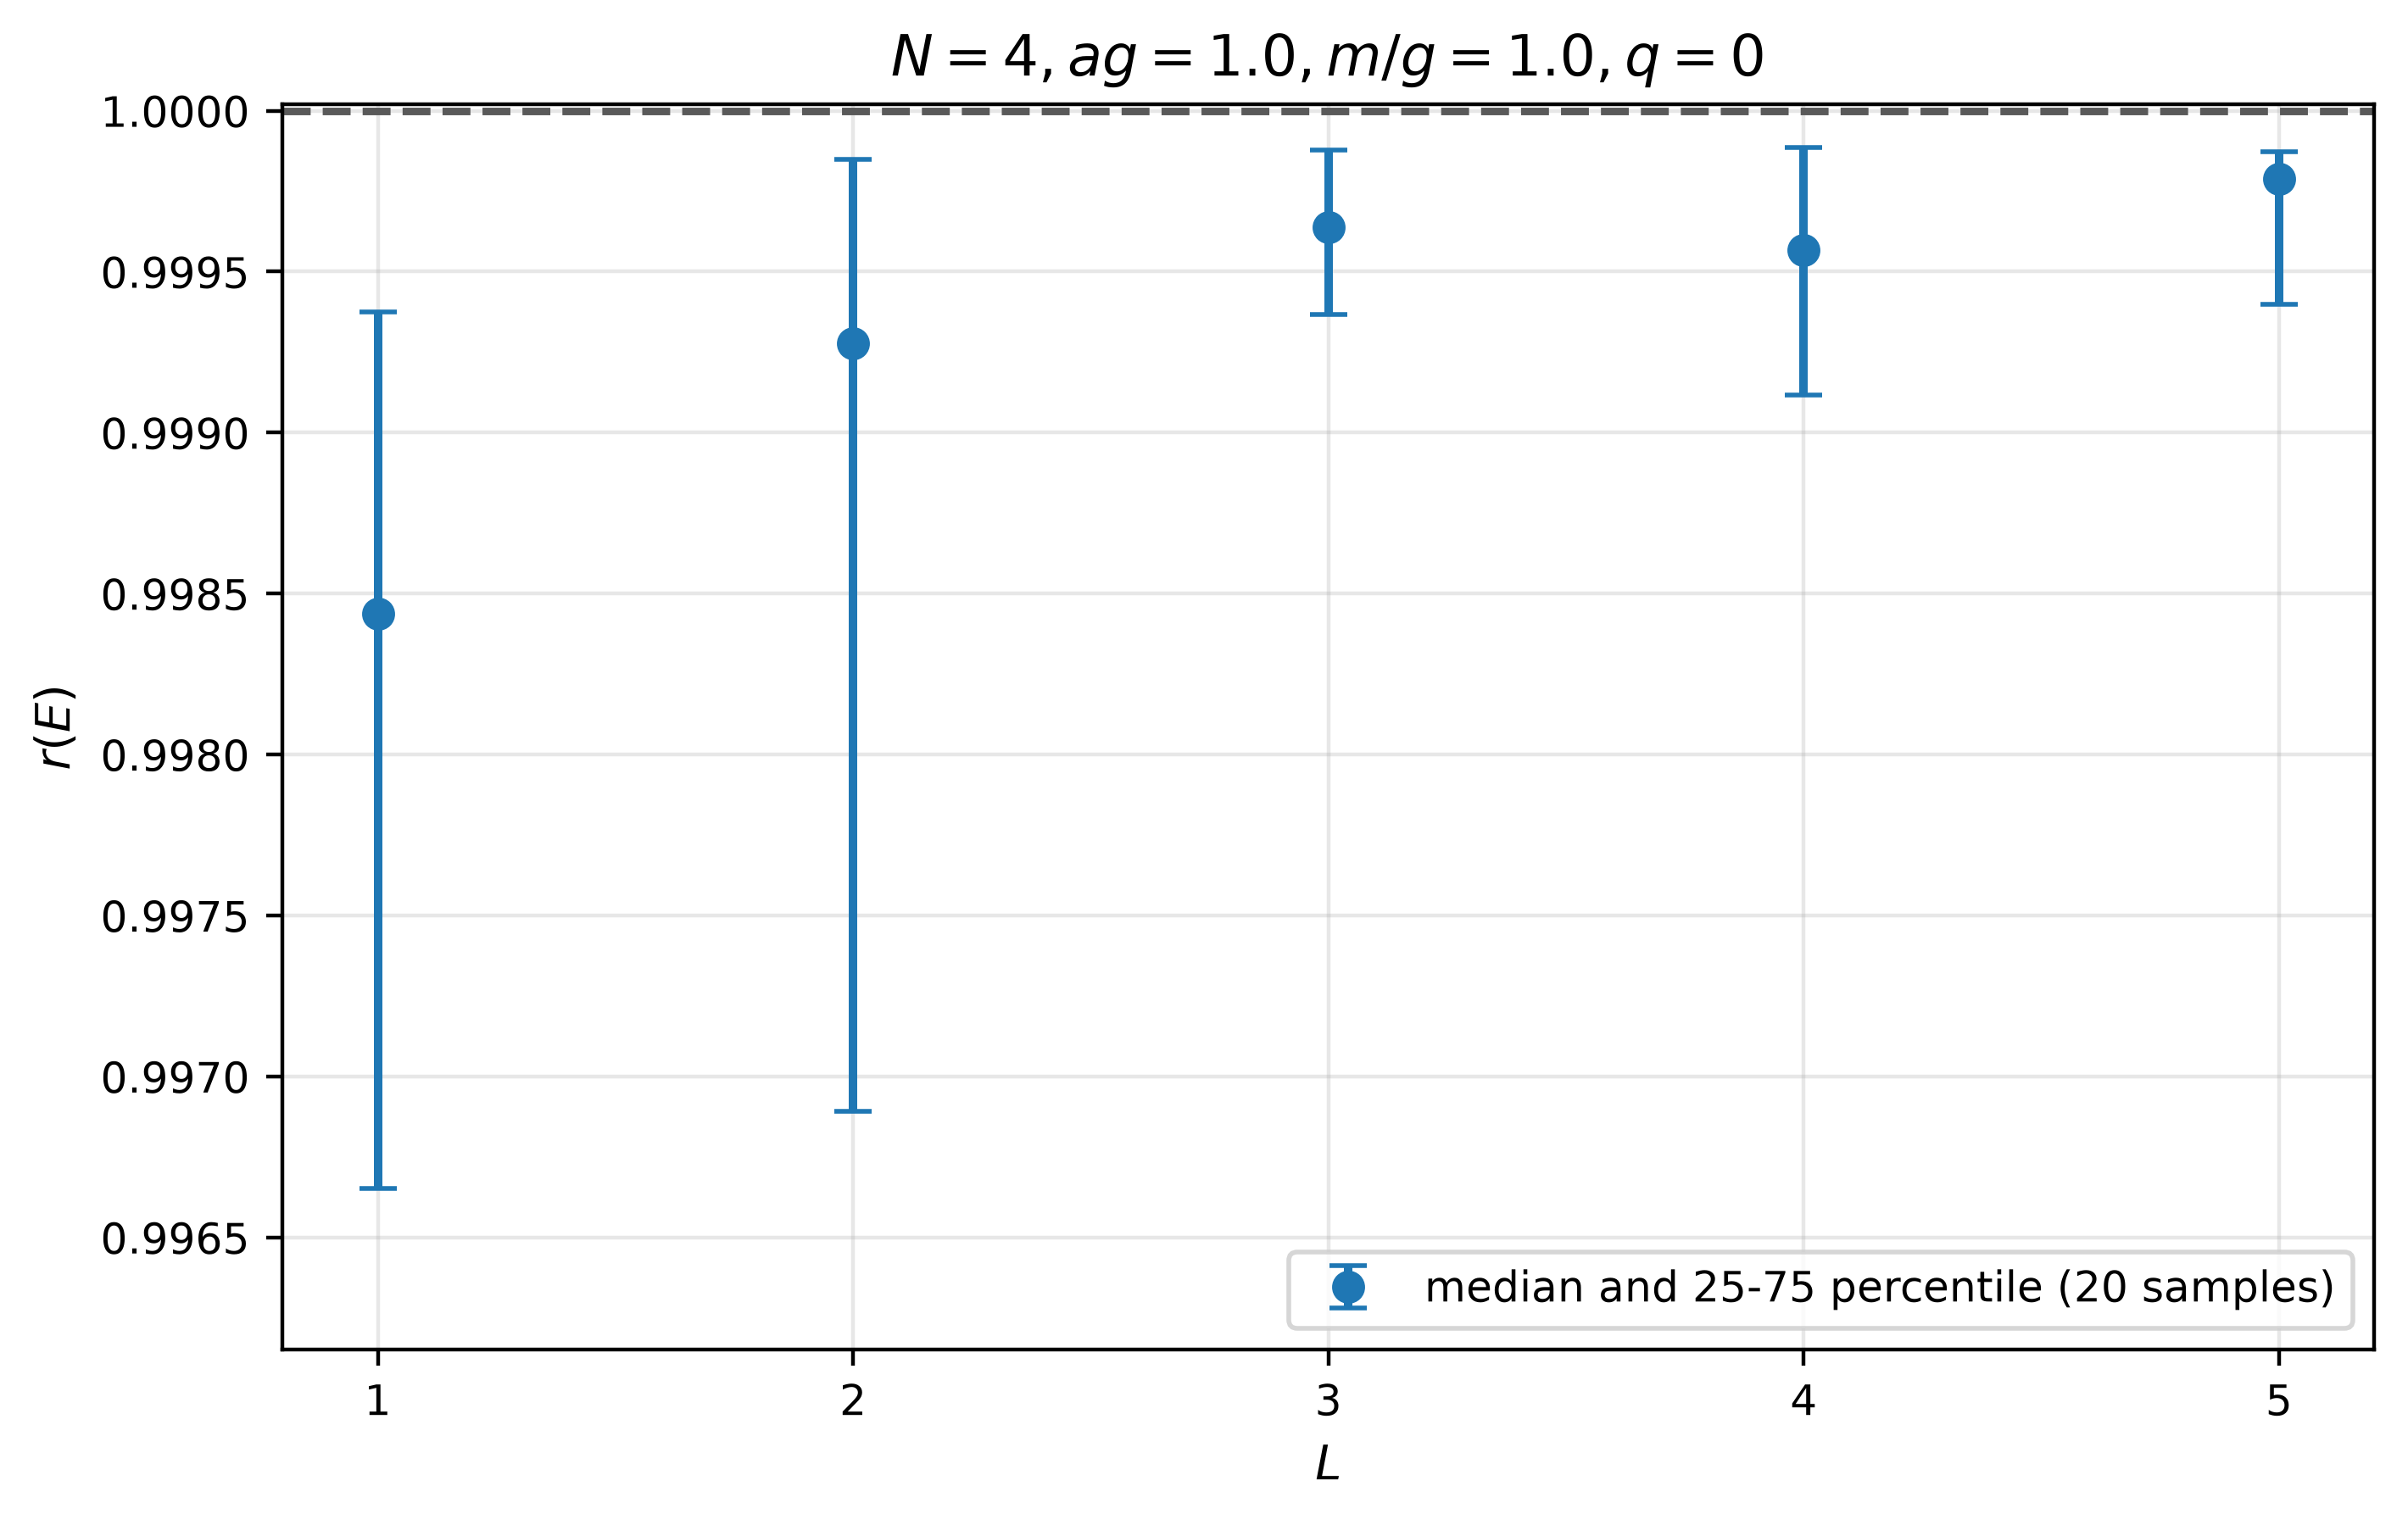

In [18]:
def run_layer_sweep_distribution(l_values, physics_config, vqe_config, include_zero_init=False):
    H_initial = core_lib.build_schwinger_hamiltonian(
        N=physics_config["N"], ag=physics_config["ag"], m_over_g=physics_config["m_over_g"],
        external_field=physics_config["q_initial"], g=physics_config["g"],
    )
    rows = []
    for layer_count in l_values:
        result = run_vqe(H_initial, layer_count, vqe_config["n_restarts"], vqe_config["seed"],
                         vqe_config["learning_rate"], vqe_config["max_steps"], vqe_config["grad_tol"],
                         vqe_config["stall_window"], vqe_config["stall_tol"], False)
        denom = result.exact_max_energy - result.exact_ground_energy
        records = [r for r in result.restart_history if isinstance(r["restart"], int) and (include_zero_init or r["restart"] != 0)]
        restart_r_E = onp.array([(result.exact_max_energy - r["energy"]) / denom for r in records])
        rows.append({"L": layer_count, "r_E_mean": float(onp.mean(restart_r_E)),
                     "r_E_median": float(onp.median(restart_r_E)),
                     "r_E_p25": float(onp.percentile(restart_r_E, 25)),
                     "r_E_p75": float(onp.percentile(restart_r_E, 75)),
                     "sample_count": int(restart_r_E.size)})
    return rows

if RUN_LAYER_SWEEP:
    layer_sweep_rows = run_layer_sweep_distribution(LAYER_SWEEP_L_VALUES, PHYSICS_CONFIG, LAYER_SWEEP_VQE_CONFIG, LAYER_SWEEP_INCLUDE_ZERO_INIT)
    layer_values = onp.array([row["L"] for row in layer_sweep_rows], dtype=int)
    r_median = onp.array([row["r_E_median"] for row in layer_sweep_rows], dtype=float)
    r_p25 = onp.array([row["r_E_p25"] for row in layer_sweep_rows], dtype=float)
    r_p75 = onp.array([row["r_E_p75"] for row in layer_sweep_rows], dtype=float)

    fig, ax = plt.subplots(figsize=PLOT_SINGLE_FIGSIZE)
    ax.errorbar(
        layer_values,
        r_median,
        yerr=[r_median - r_p25, r_p75 - r_median],
        fmt="o",
        capsize=4,
        color="C0",
        ecolor="C0",
        label=f"median and 25-75 percentile ({layer_sweep_rows[0]['sample_count']} samples)",
    )
    ax.axhline(1.0, color="0.35", linestyle="--", linewidth=1.6)
    ax.set_xlabel(r"$L$")
    ax.set_ylabel(r"$r(E)$")
    ax.set_title(
        rf"$N={PHYSICS_CONFIG['N']}, ag={PHYSICS_CONFIG['ag']:.1f}, "
        rf"m/g={PHYSICS_CONFIG['m_over_g']:.1f}, q={PHYSICS_CONFIG['q_initial']:.0f}$"
    )
    ax.set_xticks(layer_values)
    y_min = float(onp.min(r_p25))
    margin = max(1e-5, 0.15 * max(1e-8, 1.0 - y_min))
    ax.set_ylim(max(0.0, y_min - margin), 1.00002)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")
    fig.tight_layout()
    plt.show()
else:
    layer_sweep_rows = []
    print("Layer sweep skipped. Set RUN_LAYER_SWEEP = True to generate the r(E) distribution plot.")


## 5. Validation Gate and Downstream Input


In [19]:
module1_ready = module1_acceptance_passed(module1_metadata["validation"])
module2_ready = module2_acceptance_passed(module2_metadata["validation"])
print("Module 1 ready for quench:", module1_ready)
print("Module 2 ready for dynamics:", module2_ready)
assert module1_ready, "Module 1 VQE validation failed."
assert module2_ready, "Module 2 quench validation failed."

module2_downstream_input = {
    "module1_config": module1_metadata["config"],
    "module2_config": module2_metadata["config"],
    "theta_opt": module1_arrays["theta_opt"],
    "psi_0": module2_arrays["psi_0"],
    "H_initial_matrix": module2_arrays["H_initial_matrix"],
    "H_final_matrix": module2_arrays["H_final_matrix"],
}
for key, value in module2_downstream_input.items():
    print(f"{key}:", getattr(value, "shape", value))


Module 1 ready for quench: True
Module 2 ready for dynamics: True
module1_config: {'N': 4, 'ag': 1.0, 'm_over_g': 1.0, 'q_initial': 0.0, 'g': 1.0, 'layer_count': 5, 'n_restarts': 10, 'seed': 1234, 'learning_rate': 0.05, 'max_steps': 200, 'grad_tol': 0.0001, 'stall_window': 100, 'stall_tol': 1e-09, 'use_lbfgs_polish': False}
module2_config: {'N': 4, 'ag': 1.0, 'm_over_g': 1.0, 'q_initial': 0.0, 'q_final': 2.0, 'g': 1.0, 'layer_count': 5}
theta_opt: (50,)
psi_0: (16,)
H_initial_matrix: (16, 16)
H_final_matrix: (16, 16)


## 6. Module 3 Suzuki-Trotter Quench Baseline


In [20]:
module3_psi_0 = onp.asarray(module2_downstream_input["psi_0"], dtype=complex)
if USE_TEST_DATA_INPUT and MODULE3_METADATA_PATH.exists() and not REGENERATE_TEST_DATA:
    module3_metadata, module3_arrays = load_module_test_data("module3_trotter")
    print("Loaded Module 3 fixture:", display_path(MODULE3_METADATA_PATH))
else:
    module3_config = make_module3_config()
    module3_result = run_module3_from_config(module3_config, module3_psi_0)
    module3_metadata = {
        "schema_version": 2, "module": "module3_trotter",
        "description": "Second-order Suzuki-Trotter baseline fixture for the q=2 post-quench dynamics.",
        "source_paper": "Nagano, Bapat, Bauer, arXiv:2302.10933",
        "config": module3_result.config.to_dict(), "validation": module3_result.validation,
        "convergence": {"n_steps_values": list(module3_result.convergence.n_steps_values),
                        "final_fidelity": module3_result.convergence.final_fidelity.tolist(),
                        "final_state_error": module3_result.convergence.final_state_error.tolist(),
                        "order_estimate": module3_result.convergence.order_estimate},
        "arrays_file": "arrays.npz", "array_keys": ["times", "trotter_electric_field", "trotter_chiral_condensate", "trotter_charge", "exact_electric_field", "exact_chiral_condensate", "exact_charge", "fidelity", "conv_n_steps", "conv_final_fidelity", "conv_final_state_error"],
    }
    save_metadata_arrays(module3_metadata, MODULE3_ARRAYS_PATH,
                         times=module3_result.trotter.times, trotter_electric_field=module3_result.trotter.electric_field,
                         trotter_chiral_condensate=module3_result.trotter.chiral_condensate, trotter_charge=module3_result.trotter.charge,
                         exact_electric_field=module3_result.exact.electric_field, exact_chiral_condensate=module3_result.exact.chiral_condensate,
                         exact_charge=module3_result.exact.charge, fidelity=module3_result.fidelity,
                         conv_n_steps=onp.asarray(module3_result.convergence.n_steps_values, dtype=int),
                         conv_final_fidelity=module3_result.convergence.final_fidelity,
                         conv_final_state_error=module3_result.convergence.final_state_error)
    module3_arrays = onp.load(MODULE3_ARRAYS_PATH, allow_pickle=False)
print("Module 3 F(T):", module3_metadata["validation"]["final_fidelity"])
assert module3_acceptance_passed(module3_metadata["validation"])


Loaded Module 3 fixture: ../test_data/module3_trotter/metadata.json
Module 3 F(T): 0.999999811801046


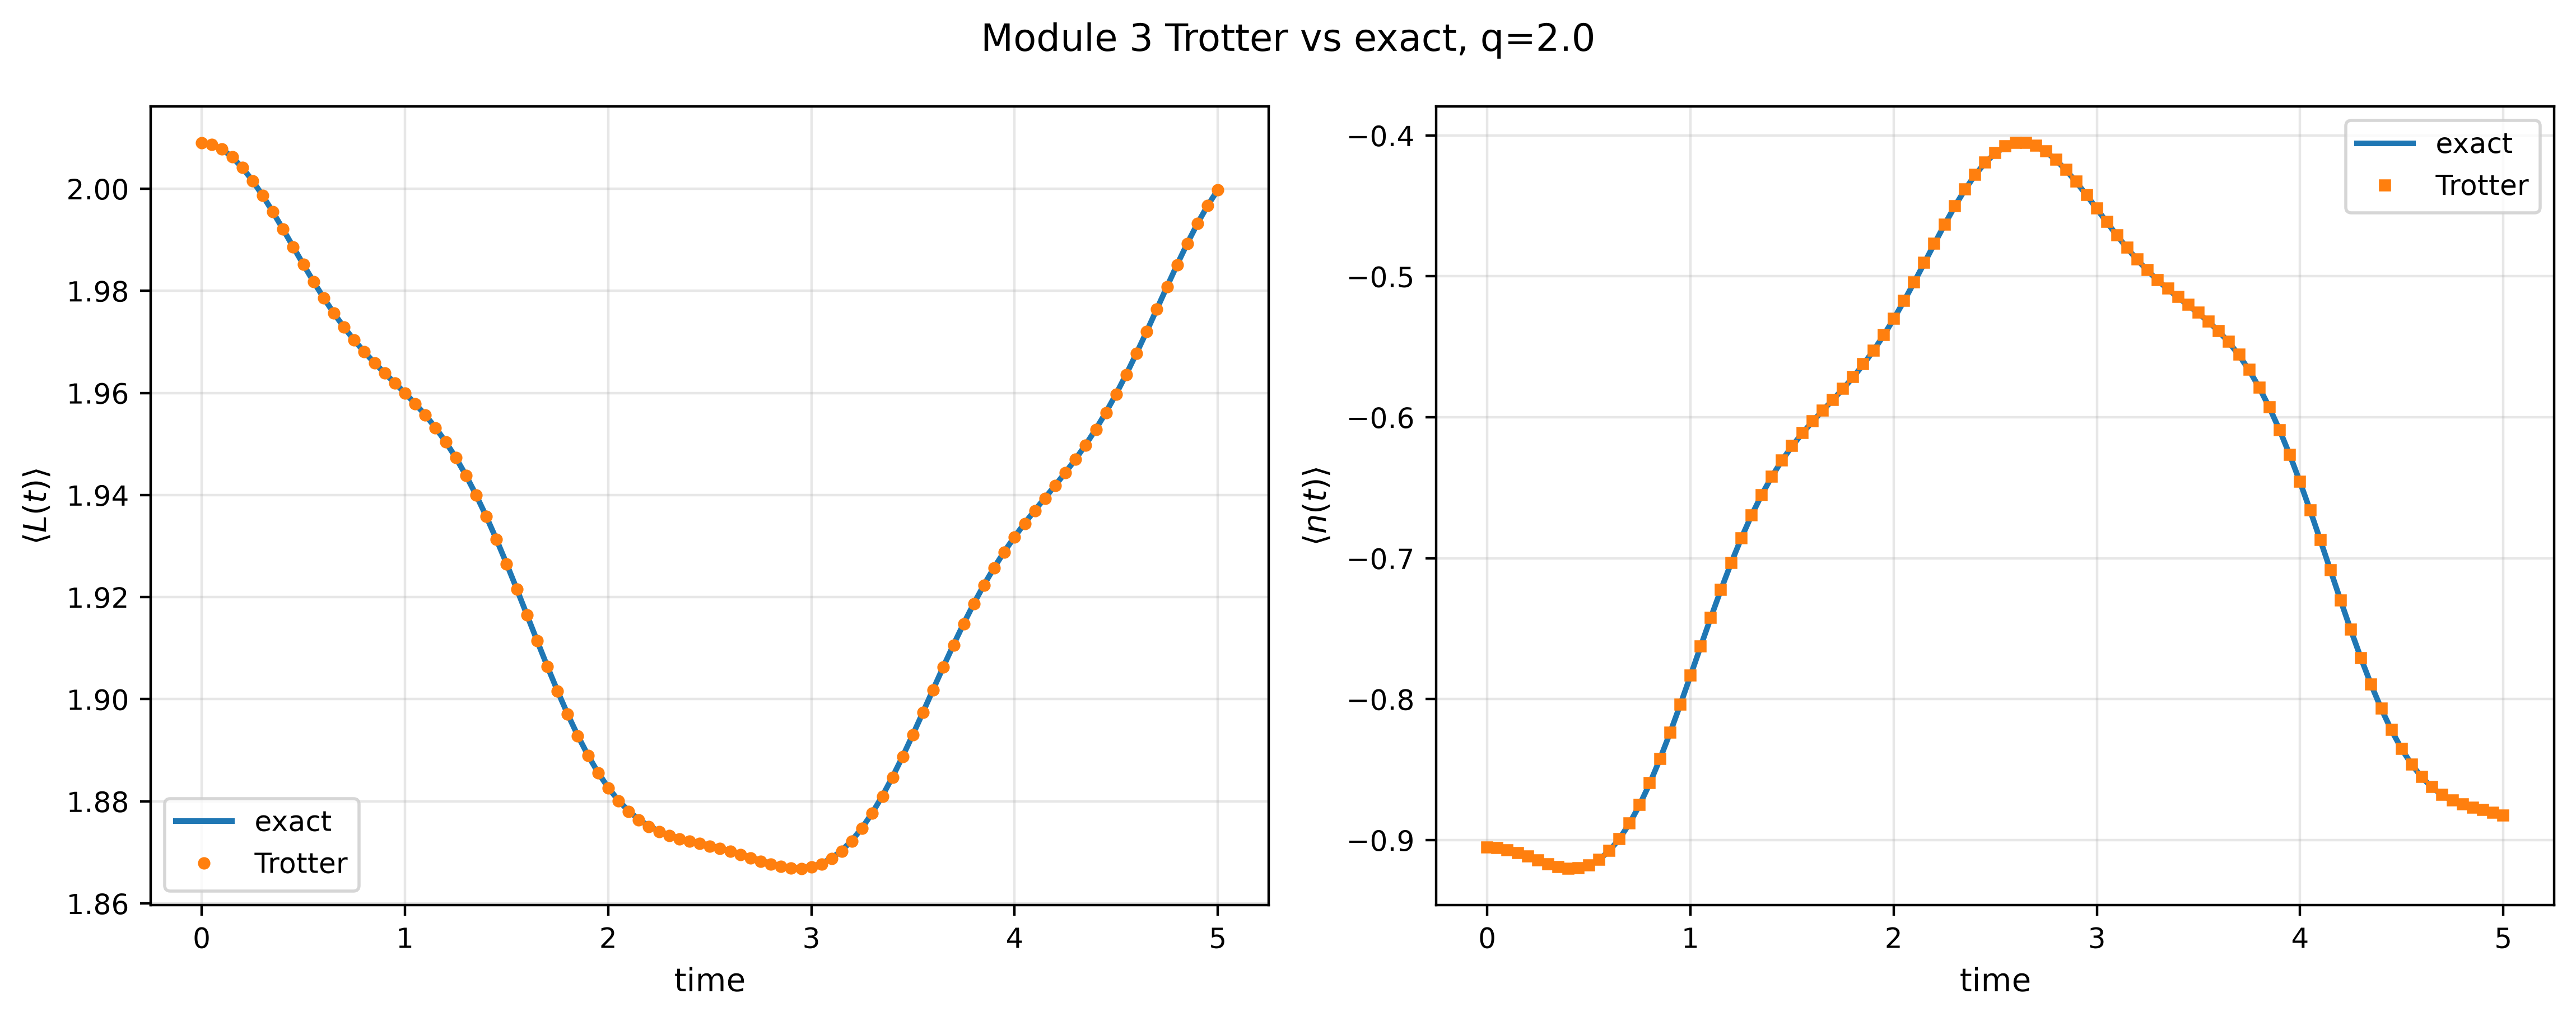

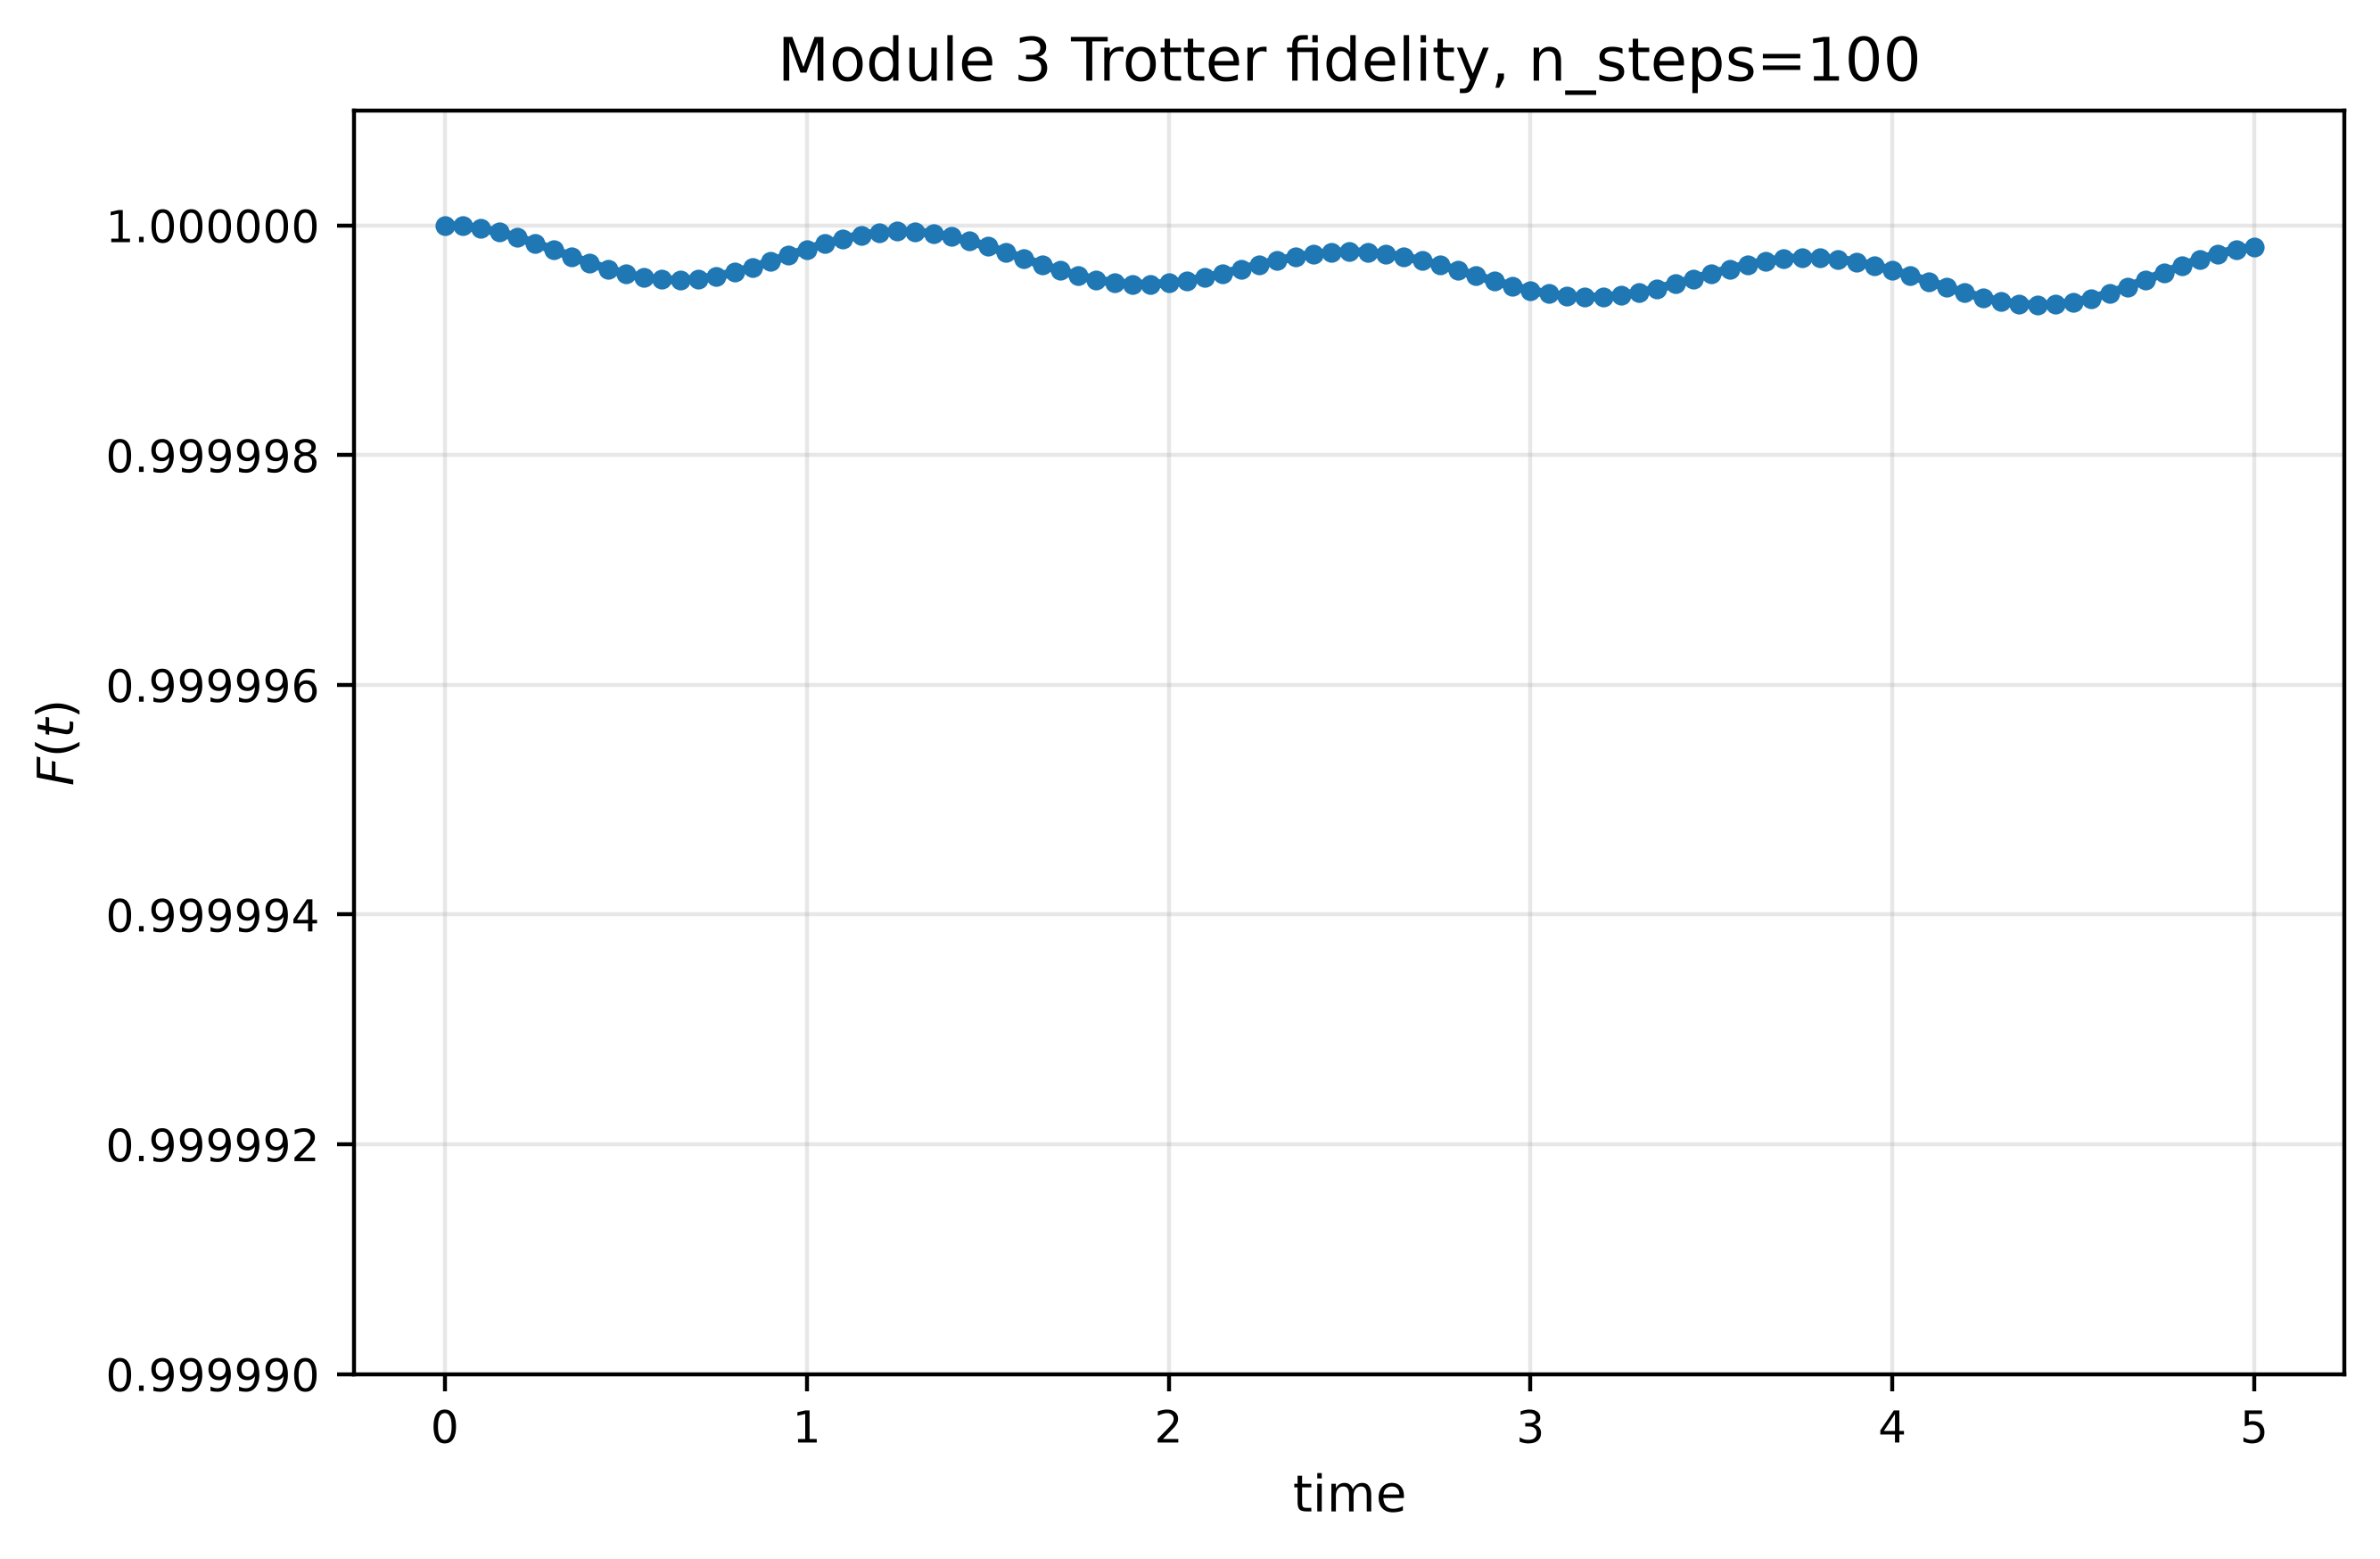

In [21]:
m3_times = module3_arrays["times"]
fig, axes = plt.subplots(1, 2, figsize=PLOT_TWO_PANEL_FIGSIZE)
axes[0].plot(m3_times, module3_arrays["exact_electric_field"], "-", label="exact")
axes[0].plot(m3_times, module3_arrays["trotter_electric_field"], "o", ms=3, label="Trotter")
axes[0].set_xlabel("time"); axes[0].set_ylabel(r"$\langle L(t)\rangle$");
axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[1].plot(m3_times, module3_arrays["exact_chiral_condensate"], "-", label="exact")
axes[1].plot(m3_times, module3_arrays["trotter_chiral_condensate"], "s", ms=3, label="Trotter")
axes[1].set_xlabel("time"); axes[1].set_ylabel(r"$\langle n(t)\rangle$"); axes[1].grid(True, alpha=0.3); axes[1].legend()
fig.suptitle(f"Module 3 Trotter vs exact, q={module3_metadata['config']['q_final']}")
fig.tight_layout(); plt.show()

plt.figure(figsize=PLOT_SINGLE_FIGSIZE)
plt.plot(m3_times, module3_arrays["fidelity"], "-o", ms=3)
plt.xlabel("time"); plt.ylabel(r"$F(t)$")
plt.title(f"Module 3 Trotter fidelity, n_steps={module3_metadata['config']['n_steps']}")
plt.grid(True, alpha=0.3); plt.ticklabel_format(axis="y", style="plain", useOffset=False); plt.ylim(0.99999, 1.000001); plt.show()


## 7. Module 4 McLachlan Variational Quantum Simulation


### 7.1 Module 4 Ensemble Fixture

In [22]:
def module4_dt_key(dt):
    return f"{float(dt):.8g}".replace("-", "m").replace(".", "p")


def module4_n_steps(total_time, dt):
    n_steps = int(round(float(total_time) / float(dt)))
    if not onp.isclose(n_steps * float(dt), float(total_time), rtol=0.0, atol=1e-12):
        raise ValueError(f"dt={dt} does not evenly divide total_time={total_time}.")
    return n_steps


def module4_percentiles(values):
    p25, median, p75 = onp.nanpercentile(values, [25, 50, 75], axis=0)
    return p25, median, p75


def safe_ratio(numerator, denominator, eps=MODULE4_RATIO_EPS):
    numerator = onp.asarray(numerator, dtype=float)
    denominator = onp.asarray(denominator, dtype=float)
    ratio = onp.full(numerator.shape, onp.nan, dtype=float)
    mask = onp.abs(denominator) > eps
    ratio[mask] = numerator[mask] / denominator[mask]
    return ratio


def module4_required_array_keys():
    keys = set()
    for layer_count in MODULE4_LAYER_VALUES:
        keys.update({
            f"layer_{layer_count}_times",
            f"layer_{layer_count}_fidelity",
            f"layer_{layer_count}_sample_energy",
            f"layer_{layer_count}_sample_r_E",
        })
    keys.add(f"layer_{MODULE4_FIXED_LAYER}_suzuki_fidelity")
    for dt in MODULE4_DT_VALUES:
        dt_key = module4_dt_key(dt)
        keys.update({f"dt_{dt_key}_times", f"dt_{dt_key}_fidelity", f"dt_{dt_key}_suzuki_fidelity"})
    keys.update({
        "obs_times",
        "obs_vqs_electric_field", "obs_ed_electric_field", "obs_suzuki_electric_field",
        "obs_vqs_chiral_condensate", "obs_ed_chiral_condensate", "obs_suzuki_chiral_condensate",
        "obs_ratio_vqs_electric_field", "obs_ratio_suzuki_electric_field",
        "obs_ratio_vqs_chiral_condensate", "obs_ratio_suzuki_chiral_condensate",
    })
    return keys


def module4_missing_fixture_keys(metadata, arrays):
    required = module4_required_array_keys()
    metadata_keys = set(metadata.get("array_keys", []))
    array_keys = set(arrays.files)
    return sorted((required - metadata_keys) | (required - array_keys))


def run_module4_ensemble_sample(theta, layer_count, dt, include_suzuki=False):
    quench = module2_lib.prepare_quench_state(
        lambda_opt=theta,
        layer_count=layer_count,
        N=PHYSICS_CONFIG["N"],
        ag=PHYSICS_CONFIG["ag"],
        m_over_g=PHYSICS_CONFIG["m_over_g"],
        q_initial=PHYSICS_CONFIG["q_initial"],
        q_final=PHYSICS_CONFIG["q_final"],
        g=PHYSICS_CONFIG["g"],
    )
    n_steps = module4_n_steps(MODULE4_TOTAL_TIME, dt)
    trajectory = module4_lib.run_vqs_evolution(
        theta,
        quench.H_final_matrix,
        layer_count,
        PHYSICS_CONFIG["N"],
        MODULE4_TOTAL_TIME,
        n_steps,
        VQS_CONFIG["regularization"],
        VQS_CONFIG["use_projector"],
    )
    exact_states = core_lib.exact_time_evolution(quench.H_final_matrix, quench.psi_0, trajectory.times)
    vqs_obs = core_lib.observable_trajectory(
        trajectory.times,
        trajectory.states,
        PHYSICS_CONFIG["N"],
        PHYSICS_CONFIG["ag"],
        PHYSICS_CONFIG["q_final"],
        PHYSICS_CONFIG["g"],
    )
    ed_obs = core_lib.observable_trajectory(
        trajectory.times,
        exact_states,
        PHYSICS_CONFIG["N"],
        PHYSICS_CONFIG["ag"],
        PHYSICS_CONFIG["q_final"],
        PHYSICS_CONFIG["g"],
    )
    record = {
        "times": trajectory.times,
        "fidelity": core_lib.fidelity_series(exact_states, trajectory.states),
        "vqs_electric_field": vqs_obs.electric_field,
        "vqs_chiral_condensate": vqs_obs.chiral_condensate,
        "ed_electric_field": ed_obs.electric_field,
        "ed_chiral_condensate": ed_obs.chiral_condensate,
    }
    if include_suzuki:
        diagonal_terms, hopping_terms = module3_lib.split_hamiltonian_terms(quench.H_final)
        H_diag = module3_lib.group_matrix(quench.H_final, diagonal_terms)
        H_hop = module3_lib.group_matrix(quench.H_final, hopping_terms)
        suzuki_times, suzuki_states = module3_lib.trotter_evolve(quench.psi_0, H_diag, H_hop, MODULE4_TOTAL_TIME, n_steps)
        if not onp.allclose(suzuki_times, trajectory.times):
            raise ValueError("Suzuki and VQS time grids do not match.")
        suzuki_obs = core_lib.observable_trajectory(
            suzuki_times,
            suzuki_states,
            PHYSICS_CONFIG["N"],
            PHYSICS_CONFIG["ag"],
            PHYSICS_CONFIG["q_final"],
            PHYSICS_CONFIG["g"],
        )
        record.update({
            "suzuki_fidelity": core_lib.fidelity_series(exact_states, suzuki_states),
            "suzuki_electric_field": suzuki_obs.electric_field,
            "suzuki_chiral_condensate": suzuki_obs.chiral_condensate,
        })
    return record


def build_module4_ensemble_data():
    H_initial = core_lib.build_schwinger_hamiltonian(
        N=PHYSICS_CONFIG["N"],
        ag=PHYSICS_CONFIG["ag"],
        m_over_g=PHYSICS_CONFIG["m_over_g"],
        external_field=PHYSICS_CONFIG["q_initial"],
        g=PHYSICS_CONFIG["g"],
    )
    all_layers = sorted(set(MODULE4_LAYER_VALUES) | {MODULE4_FIXED_LAYER})
    ensembles = {}
    for layer_count in all_layers:
        ensembles[layer_count] = run_vqe_restart_ensemble(
            H_initial=H_initial,
            layer_count=layer_count,
            n_samples=MODULE4_SAMPLE_COUNT,
            seed=VQE_REPRO_CONFIG["seed"],
            learning_rate=VQE_REPRO_CONFIG["learning_rate"],
            max_steps=VQE_REPRO_CONFIG["max_steps"],
            grad_tol=VQE_REPRO_CONFIG["grad_tol"],
            stall_window=VQE_REPRO_CONFIG["stall_window"],
            stall_tol=VQE_REPRO_CONFIG["stall_tol"],
        )

    arrays = {}
    sample_cache = {}
    for layer_count in MODULE4_LAYER_VALUES:
        include_suzuki = layer_count == MODULE4_FIXED_LAYER
        records = [
            run_module4_ensemble_sample(sample.theta_opt, layer_count, MODULE4_FIXED_DT, include_suzuki=include_suzuki)
            for sample in ensembles[layer_count].samples
        ]
        sample_cache[(layer_count, MODULE4_FIXED_DT)] = records
        arrays[f"layer_{layer_count}_times"] = records[0]["times"]
        arrays[f"layer_{layer_count}_fidelity"] = onp.asarray([record["fidelity"] for record in records])
        arrays[f"layer_{layer_count}_sample_energy"] = onp.asarray([sample.energy for sample in ensembles[layer_count].samples])
        arrays[f"layer_{layer_count}_sample_r_E"] = onp.asarray([sample.r_E for sample in ensembles[layer_count].samples])
        if include_suzuki:
            arrays[f"layer_{layer_count}_suzuki_fidelity"] = onp.asarray([record["suzuki_fidelity"] for record in records])

    for dt in MODULE4_DT_VALUES:
        cache_key = (MODULE4_FIXED_LAYER, dt)
        if cache_key in sample_cache:
            records = sample_cache[cache_key]
        else:
            records = [
                run_module4_ensemble_sample(sample.theta_opt, MODULE4_FIXED_LAYER, dt, include_suzuki=True)
                for sample in ensembles[MODULE4_FIXED_LAYER].samples
            ]
            sample_cache[cache_key] = records
        dt_key = module4_dt_key(dt)
        arrays[f"dt_{dt_key}_times"] = records[0]["times"]
        arrays[f"dt_{dt_key}_fidelity"] = onp.asarray([record["fidelity"] for record in records])
        arrays[f"dt_{dt_key}_suzuki_fidelity"] = onp.asarray([record["suzuki_fidelity"] for record in records])

    obs_records = sample_cache[(MODULE4_FIXED_LAYER, MODULE4_FIXED_DT)]
    arrays["obs_times"] = obs_records[0]["times"]
    arrays["obs_vqs_electric_field"] = onp.asarray([record["vqs_electric_field"] for record in obs_records])
    arrays["obs_ed_electric_field"] = onp.asarray([record["ed_electric_field"] for record in obs_records])
    arrays["obs_suzuki_electric_field"] = onp.asarray([record["suzuki_electric_field"] for record in obs_records])
    arrays["obs_vqs_chiral_condensate"] = onp.asarray([record["vqs_chiral_condensate"] for record in obs_records])
    arrays["obs_ed_chiral_condensate"] = onp.asarray([record["ed_chiral_condensate"] for record in obs_records])
    arrays["obs_suzuki_chiral_condensate"] = onp.asarray([record["suzuki_chiral_condensate"] for record in obs_records])
    arrays["obs_ratio_vqs_electric_field"] = safe_ratio(arrays["obs_vqs_electric_field"], arrays["obs_ed_electric_field"])
    arrays["obs_ratio_suzuki_electric_field"] = safe_ratio(arrays["obs_suzuki_electric_field"], arrays["obs_ed_electric_field"])
    arrays["obs_ratio_vqs_chiral_condensate"] = safe_ratio(arrays["obs_vqs_chiral_condensate"], arrays["obs_ed_chiral_condensate"])
    arrays["obs_ratio_suzuki_chiral_condensate"] = safe_ratio(arrays["obs_suzuki_chiral_condensate"], arrays["obs_ed_chiral_condensate"])

    metadata = {
        "schema_version": 2,
        "module": "module4_mclachlan",
        "description": "Module 4 20-sample McLachlan VQS ensemble with ED and Suzuki references.",
        "source_paper": "Nagano, Bapat, Bauer, arXiv:2302.10933",
        "config": {
            "physics": dict(PHYSICS_CONFIG),
            "vqe": dict(VQE_REPRO_CONFIG),
            "vqs": {"regularization": VQS_CONFIG["regularization"], "use_projector": VQS_CONFIG["use_projector"]},
            "layer_values": list(MODULE4_LAYER_VALUES),
            "dt_values": list(MODULE4_DT_VALUES),
            "fixed_layer": MODULE4_FIXED_LAYER,
            "fixed_dt": MODULE4_FIXED_DT,
            "total_time": MODULE4_TOTAL_TIME,
            "sample_count": MODULE4_SAMPLE_COUNT,
            "ratio_convention": "VQS / ED and Suzuki / ED",
            "ratio_denominator_threshold": MODULE4_RATIO_EPS,
            "includes_zero_initialization": True,
        },
        "exact_spectrum": {
            str(layer): {
                "ground_energy": ensembles[layer].exact_ground_energy,
                "max_energy": ensembles[layer].exact_max_energy,
            }
            for layer in all_layers
        },
        "arrays_file": MODULE4_ARRAYS_PATH.name,
        "array_keys": sorted(arrays.keys()),
    }
    return metadata, arrays


module4_metadata = None
module4_arrays = None
module4_fixture_available = MODULE4_METADATA_PATH.exists() and MODULE4_ARRAYS_PATH.exists()
module4_should_generate = False

if USE_MODULE4_FIXTURE and module4_fixture_available and not REGENERATE_MODULE4_DATA:
    loaded_metadata, loaded_arrays = load_module_test_data("module4_mclachlan")
    missing_keys = module4_missing_fixture_keys(loaded_metadata, loaded_arrays)
    wrong_module = loaded_metadata.get("module") != "module4_mclachlan"
    if missing_keys or wrong_module:
        loaded_arrays.close()
        print("Module 4 fixture is not the current 20-sample ensemble schema.")
        if wrong_module:
            print("metadata.module:", loaded_metadata.get("module"))
        if missing_keys:
            print("Missing keys:", missing_keys)
        if RUN_MODULE4_ENSEMBLE:
            module4_should_generate = True
        else:
            print("Set RUN_MODULE4_ENSEMBLE = True or REGENERATE_MODULE4_DATA = True to regenerate it.")
    else:
        module4_metadata, module4_arrays = loaded_metadata, loaded_arrays
        print("Loaded Module 4 ensemble fixture:", display_path(MODULE4_METADATA_PATH))
elif RUN_MODULE4_ENSEMBLE:
    module4_should_generate = True

if module4_should_generate:
    print("Generating Module 4 ensemble fixture. This runs 20 VQE samples across the requested VQS/ED sweeps.")
    module4_metadata, generated_arrays = build_module4_ensemble_data()
    save_metadata_arrays(module4_metadata, MODULE4_ARRAYS_PATH, **generated_arrays)
    module4_arrays = onp.load(MODULE4_ARRAYS_PATH, allow_pickle=False)
    print("Saved Module 4 ensemble fixture:", display_path(MODULE4_METADATA_PATH))
elif module4_arrays is None and not module4_fixture_available:
    print("Module 4 ensemble plots skipped. Provide test_data/module4_mclachlan/metadata.json and module4_arrays.npz, or set RUN_MODULE4_ENSEMBLE = True.")

Loaded Module 4 ensemble fixture: ../test_data/module4_mclachlan/metadata.json


### 7.2 Fidelity Sweep: Layer Count

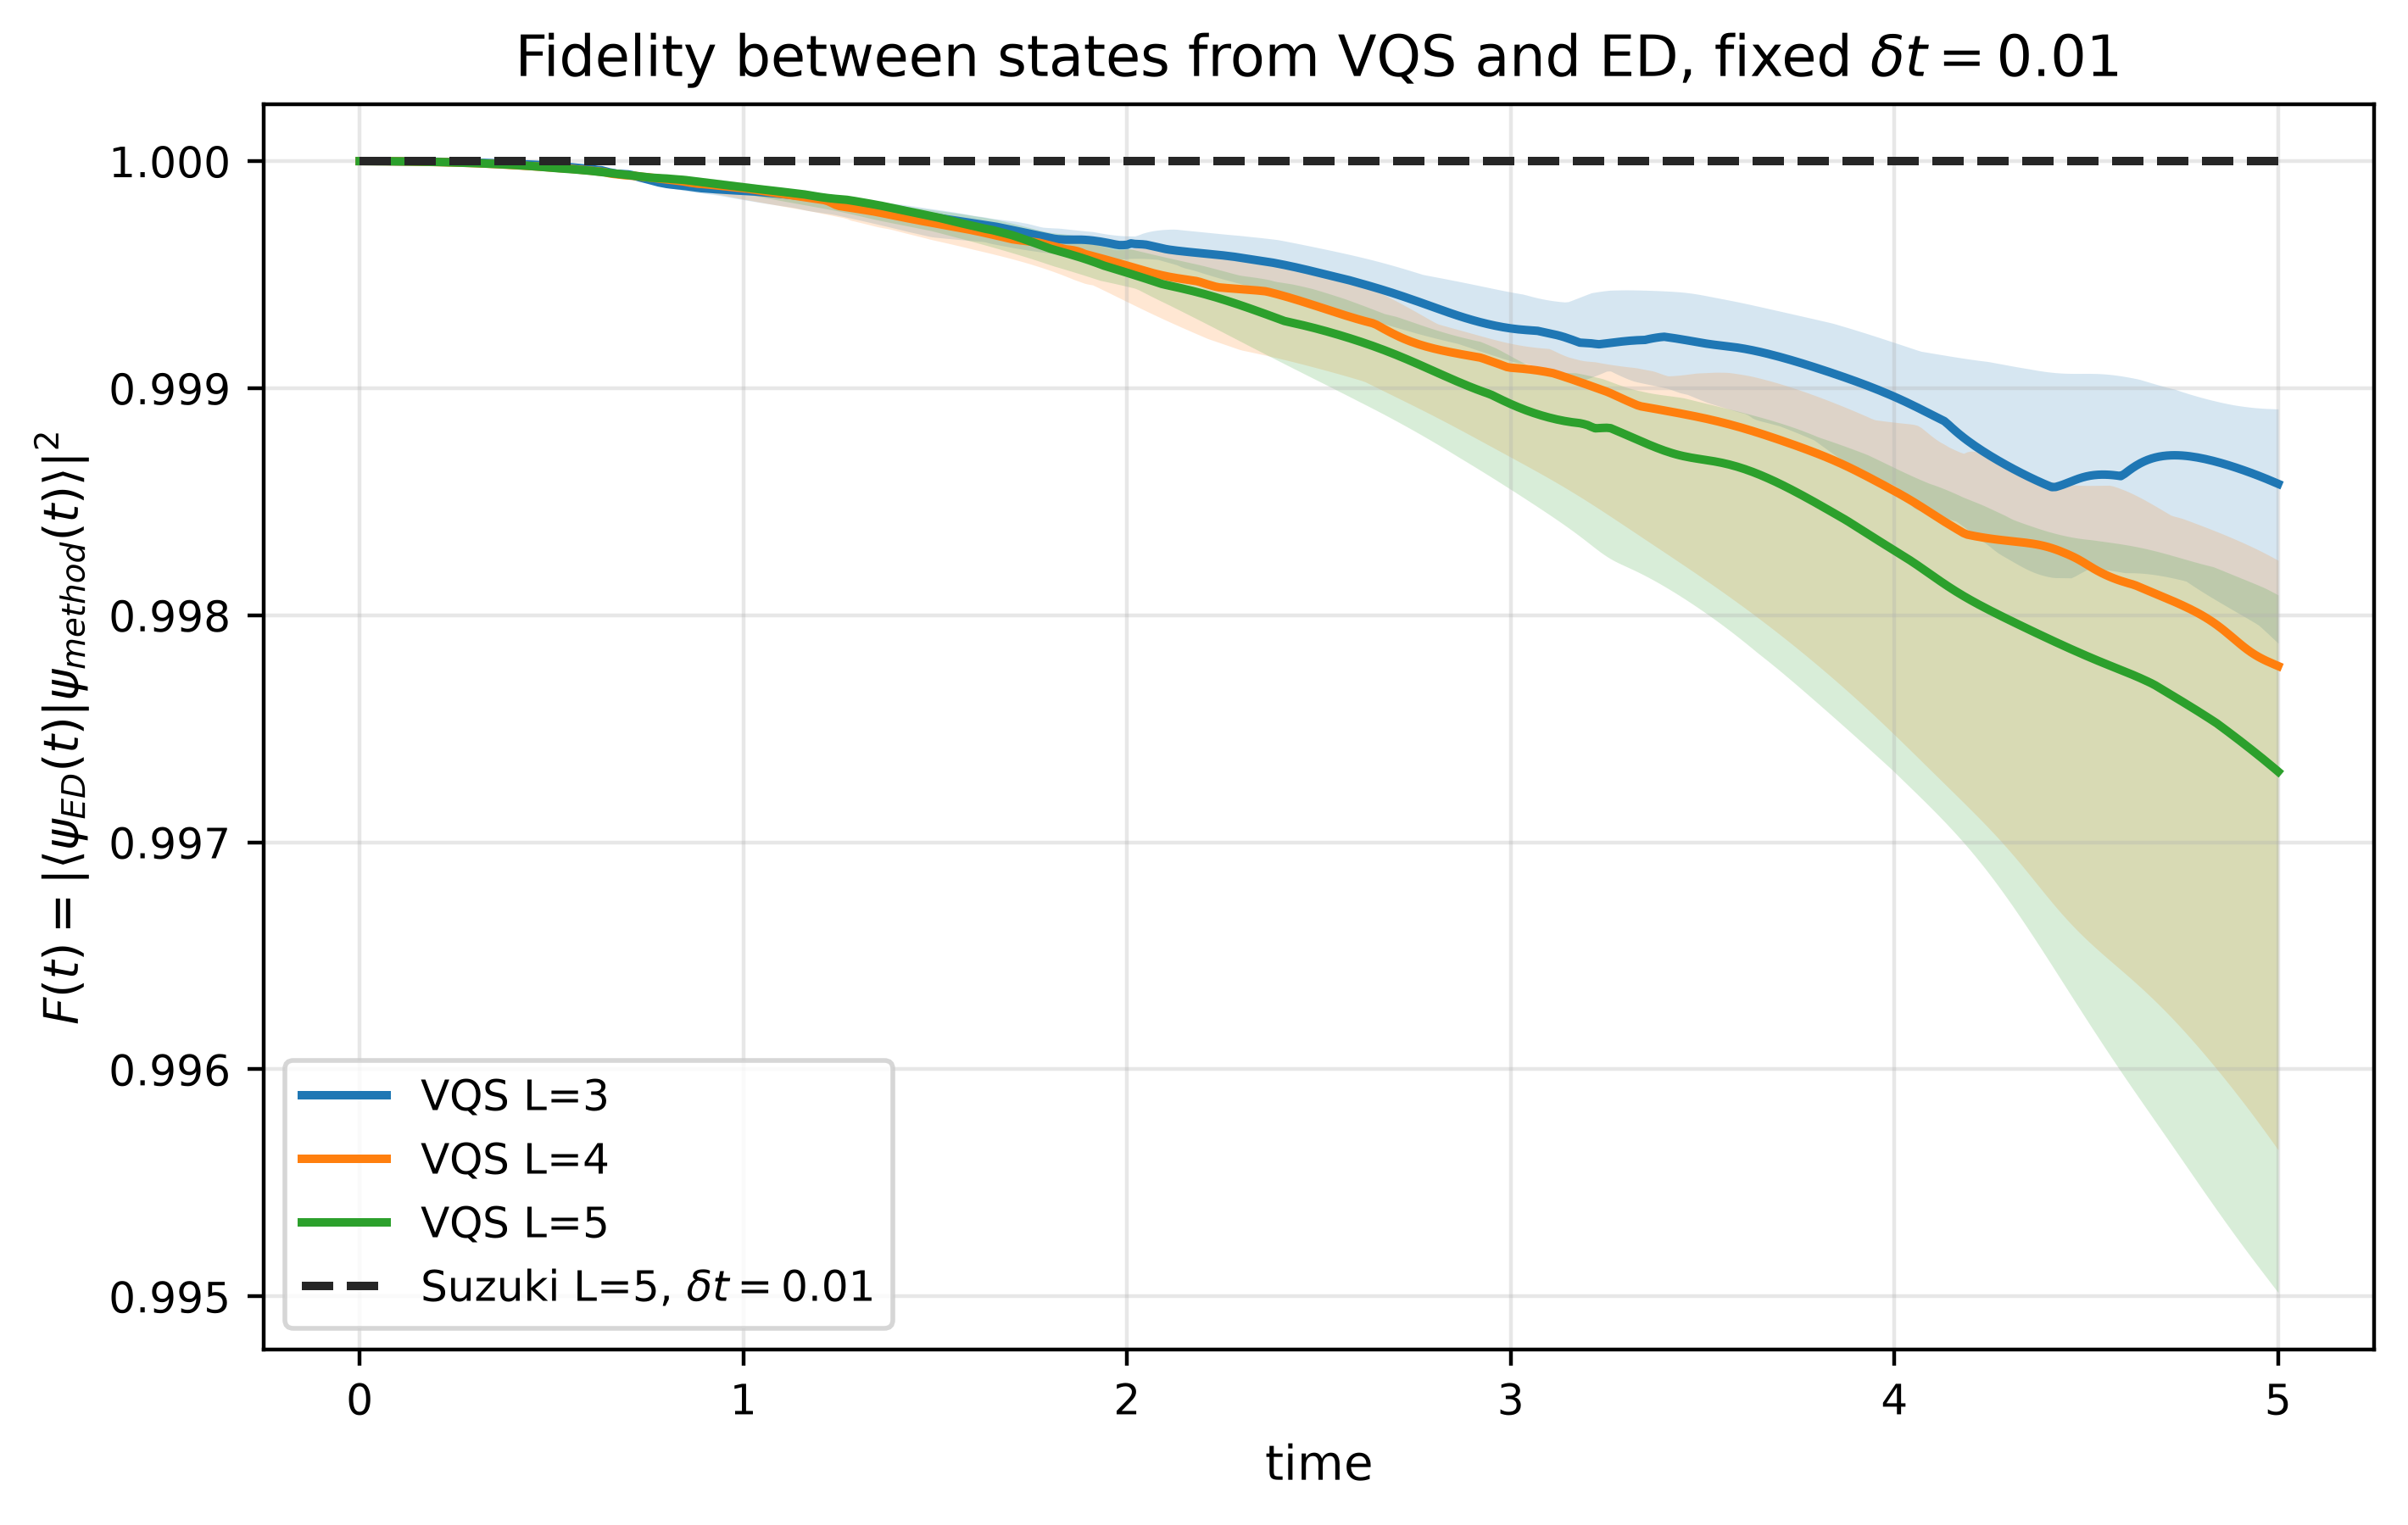

In [23]:
if module4_arrays is None:
    print("Layer sweep fidelity plot skipped because Module 4 ensemble data is unavailable.")
else:
    fig, ax = plt.subplots(figsize=PLOT_SINGLE_FIGSIZE)
    for layer_count in MODULE4_LAYER_VALUES:
        times = module4_arrays[f"layer_{layer_count}_times"]
        values = module4_arrays[f"layer_{layer_count}_fidelity"]
        p25, median, p75 = module4_percentiles(values)
        line, = ax.plot(times, median, label=f"VQS L={layer_count}")
        ax.fill_between(times, p25, p75, color=line.get_color(), alpha=0.18, linewidth=0)

    times = module4_arrays[f"layer_{MODULE4_FIXED_LAYER}_times"]
    suzuki_values = module4_arrays[f"layer_{MODULE4_FIXED_LAYER}_suzuki_fidelity"]
    p25, median, p75 = module4_percentiles(suzuki_values)
    line, = ax.plot(times, median, "--", color="0.15", label=rf"Suzuki L={MODULE4_FIXED_LAYER}, $\delta t={MODULE4_FIXED_DT}$")
    ax.fill_between(times, p25, p75, color=line.get_color(), alpha=0.12, linewidth=0)

    ax.set_xlabel("time")
    ax.set_ylabel(r"$F(t)=|\langle\psi_{ED}(t)|\psi_{method}(t)\rangle|^2$")
    ax.set_title(rf"Fidelity between states from VQS and ED, fixed $\delta t={MODULE4_FIXED_DT}$")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

### 7.3 Fidelity Sweep: Time Step

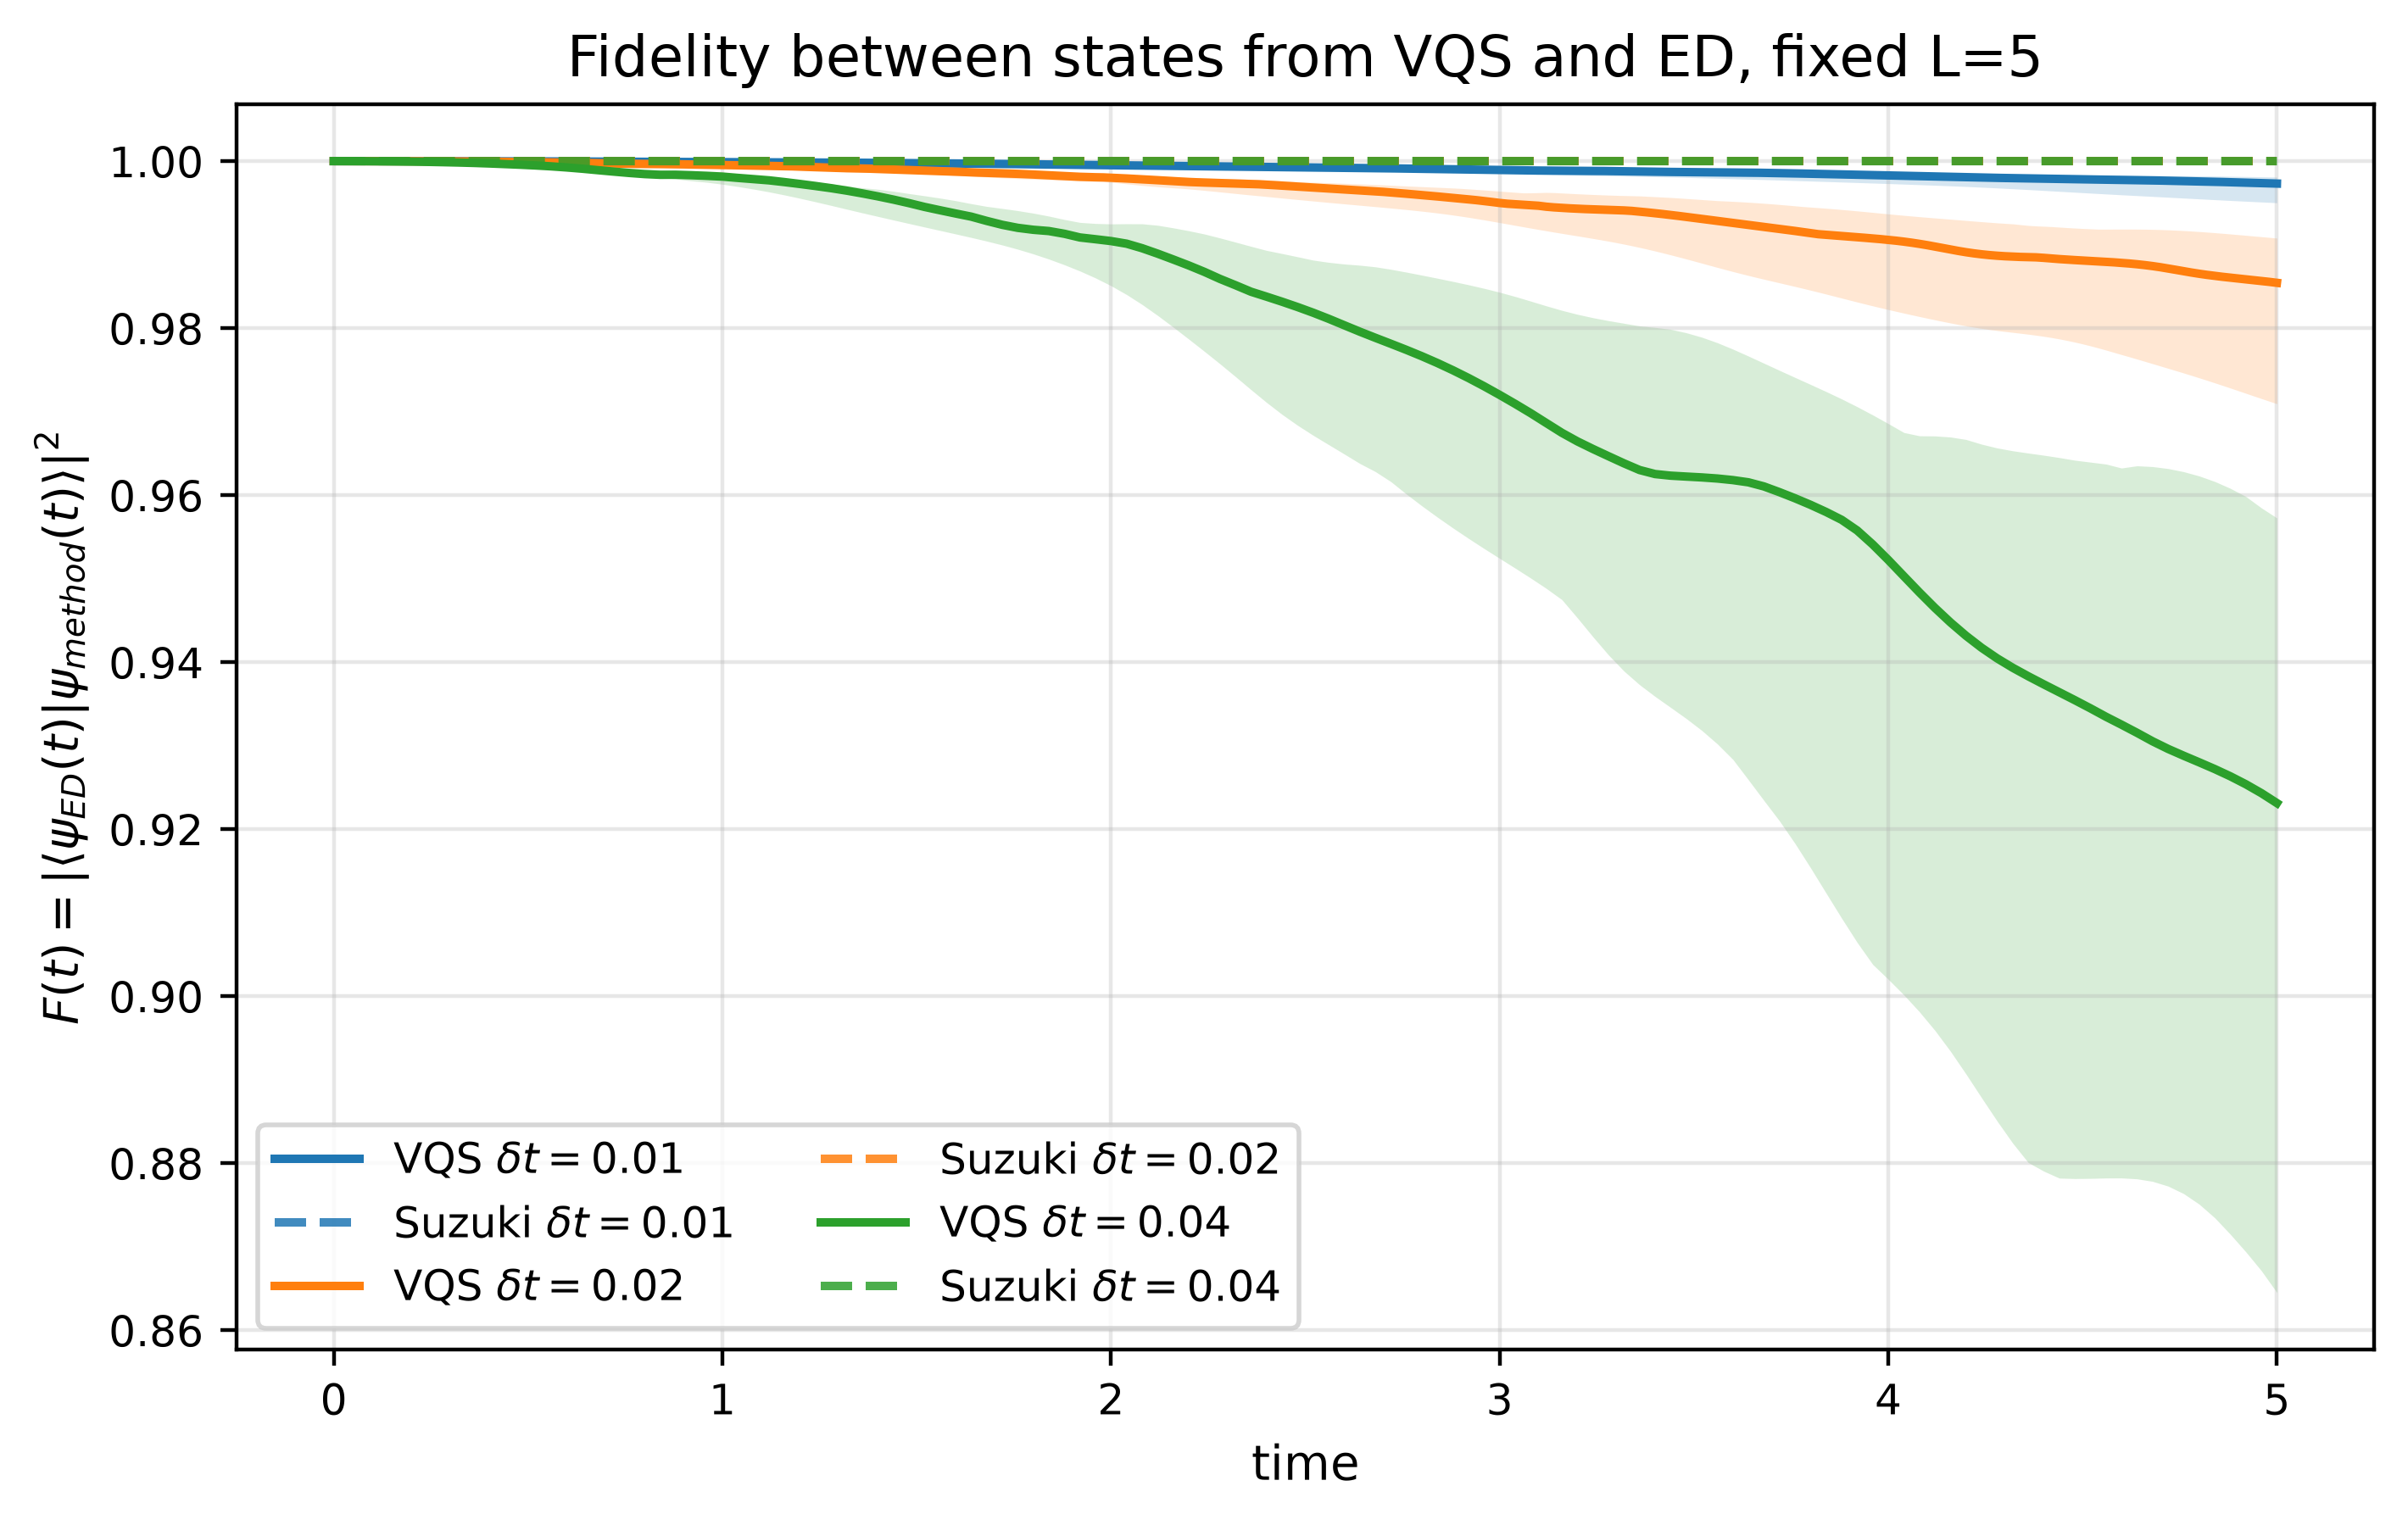

In [24]:
if module4_arrays is None:
    print("Time-step sweep fidelity plot skipped because Module 4 ensemble data is unavailable.")
else:
    fig, ax = plt.subplots(figsize=PLOT_SINGLE_FIGSIZE)
    for dt in MODULE4_DT_VALUES:
        dt_key = module4_dt_key(dt)
        times = module4_arrays[f"dt_{dt_key}_times"]
        values = module4_arrays[f"dt_{dt_key}_fidelity"]
        p25, median, p75 = module4_percentiles(values)
        line, = ax.plot(times, median, label=rf"VQS $\delta t={dt}$")
        ax.fill_between(times, p25, p75, color=line.get_color(), alpha=0.18, linewidth=0)
        suzuki_values = module4_arrays[f"dt_{dt_key}_suzuki_fidelity"]
        sp25, smedian, sp75 = module4_percentiles(suzuki_values)
        ax.plot(times, smedian, "--", color=line.get_color(), alpha=0.85, label=rf"Suzuki $\delta t={dt}$")
        ax.fill_between(times, sp25, sp75, color=line.get_color(), alpha=0.08, linewidth=0)

    ax.set_xlabel("time")
    ax.set_ylabel(r"$F(t)=|\langle\psi_{ED}(t)|\psi_{method}(t)\rangle|^2$")
    ax.set_title(f"Fidelity between states from VQS and ED, fixed L={MODULE4_FIXED_LAYER}")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2)
    fig.tight_layout()
    plt.show()

### 7.4 Expectation Values

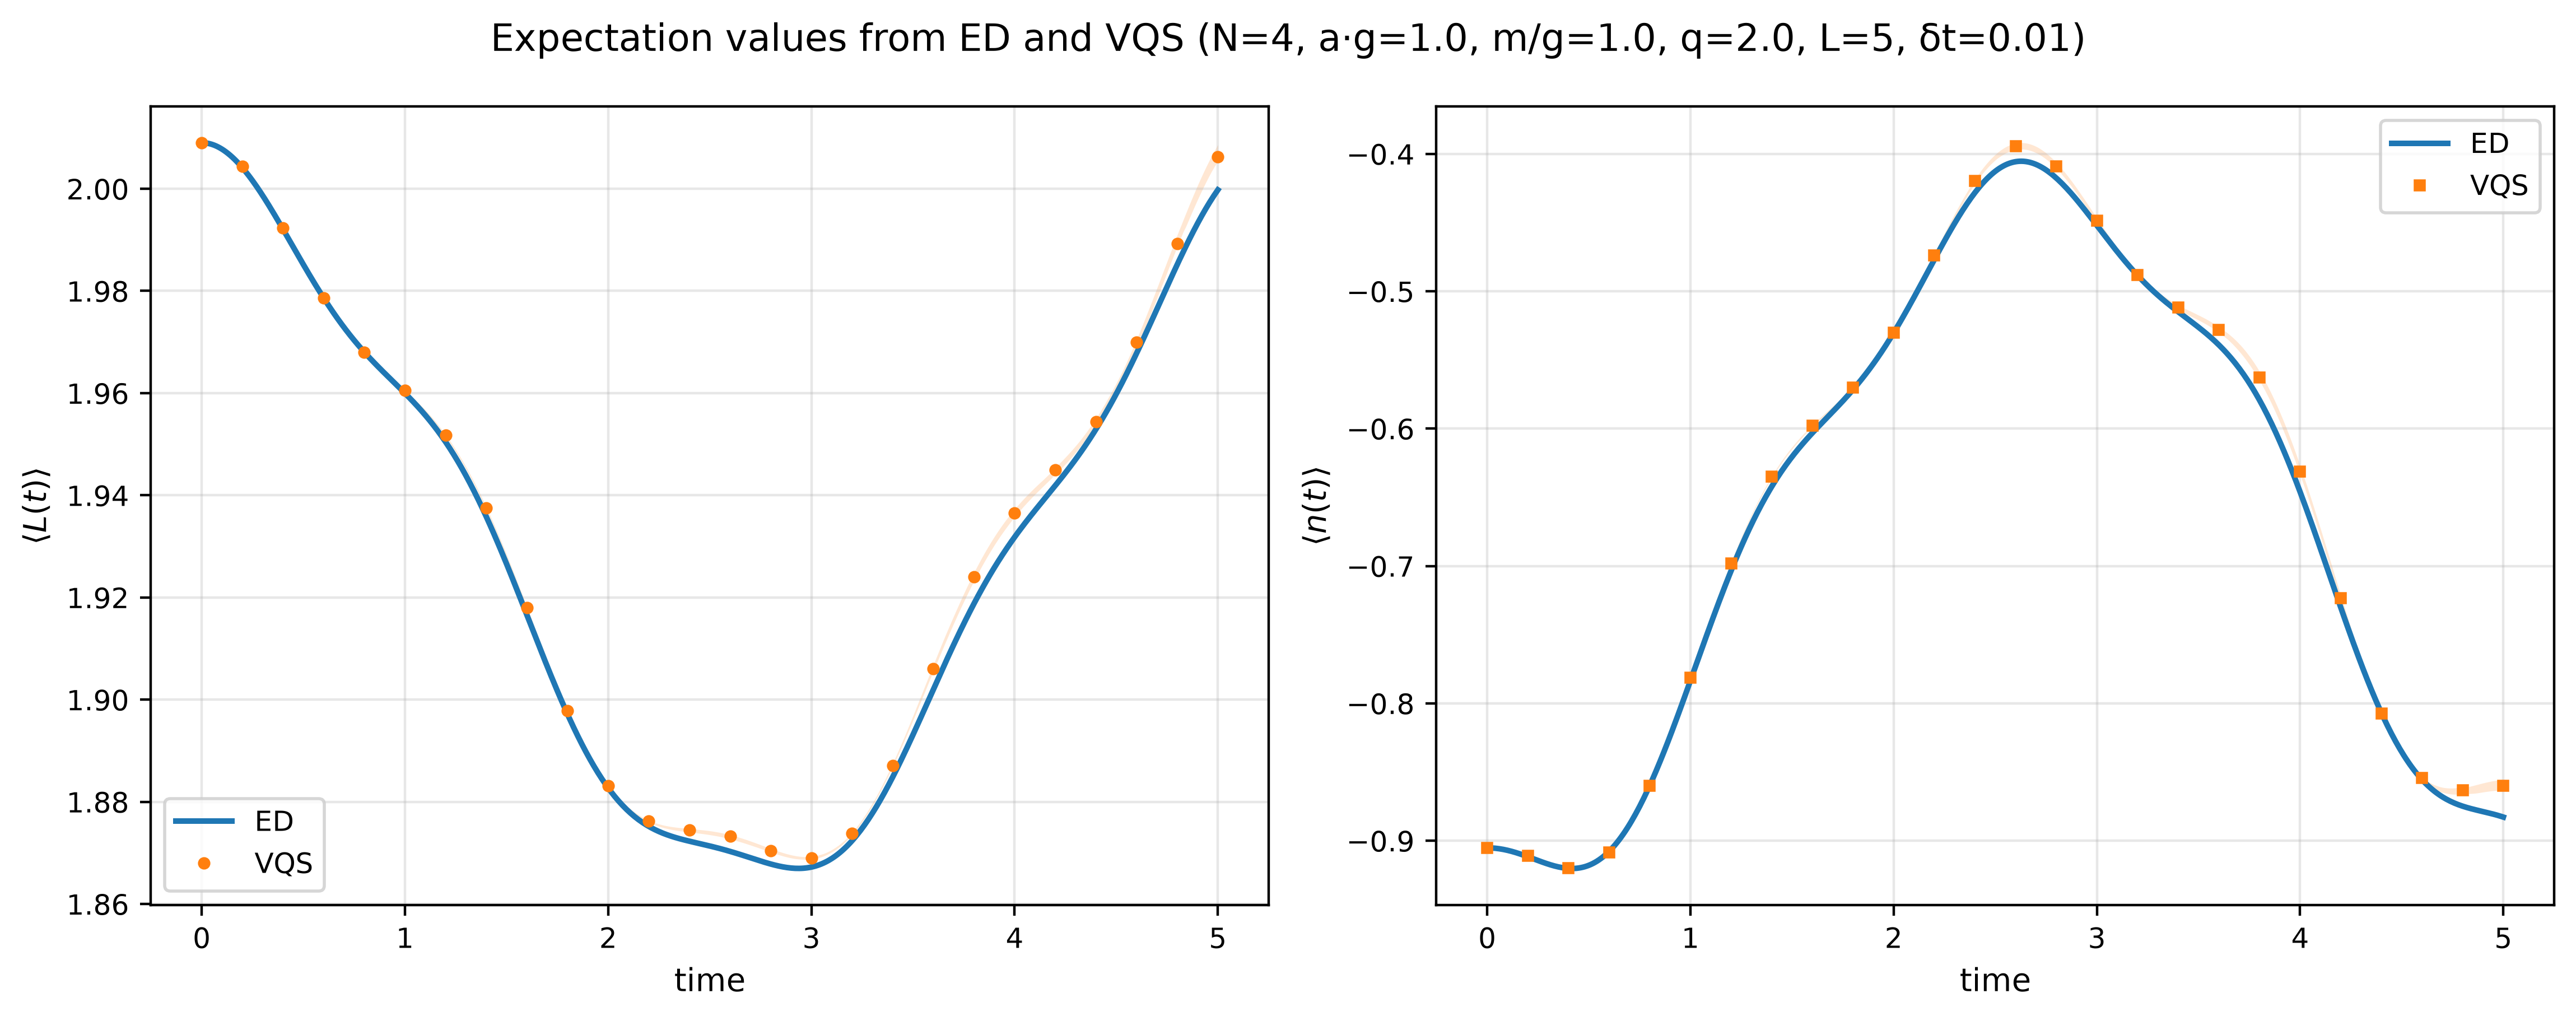

In [25]:
def plot_median_band(ax, times, values, label, linestyle="-", marker=None):
    p25, median, p75 = module4_percentiles(values)
    line, = ax.plot(times, median, linestyle=linestyle, marker=marker, markevery=max(1, len(times) // MODULE4_ERRORBAR_POINTS), ms=3, label=label)
    ax.fill_between(times, p25, p75, color=line.get_color(), alpha=0.18, linewidth=0)
    return line


if module4_arrays is None:
    print("Expectation-value plots skipped because Module 4 ensemble data is unavailable.")
else:
    times = module4_arrays["obs_times"]
    fig, axes = plt.subplots(1, 2, figsize=PLOT_TWO_PANEL_FIGSIZE)

    plot_median_band(axes[0], times, module4_arrays["obs_ed_electric_field"], "ED", linestyle="-")
    plot_median_band(axes[0], times, module4_arrays["obs_vqs_electric_field"], "VQS", linestyle="", marker="o")
    axes[0].set_xlabel("time")
    axes[0].set_ylabel(r"$\langle L(t)\rangle$")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    plot_median_band(axes[1], times, module4_arrays["obs_ed_chiral_condensate"], "ED", linestyle="-")
    plot_median_band(axes[1], times, module4_arrays["obs_vqs_chiral_condensate"], "VQS", linestyle="", marker="s")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel(r"$\langle n(t)\rangle$")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.suptitle(
        "Expectation values from ED and VQS "
        f"(N={PHYSICS_CONFIG['N']}, a·g={PHYSICS_CONFIG['ag']}, m/g={PHYSICS_CONFIG['m_over_g']}, "
        f"q={PHYSICS_CONFIG['q_final']}, L={MODULE4_FIXED_LAYER}, δt={MODULE4_FIXED_DT})"
    )
    fig.tight_layout()
    plt.show()

### 7.5 Expectation Value Ratios

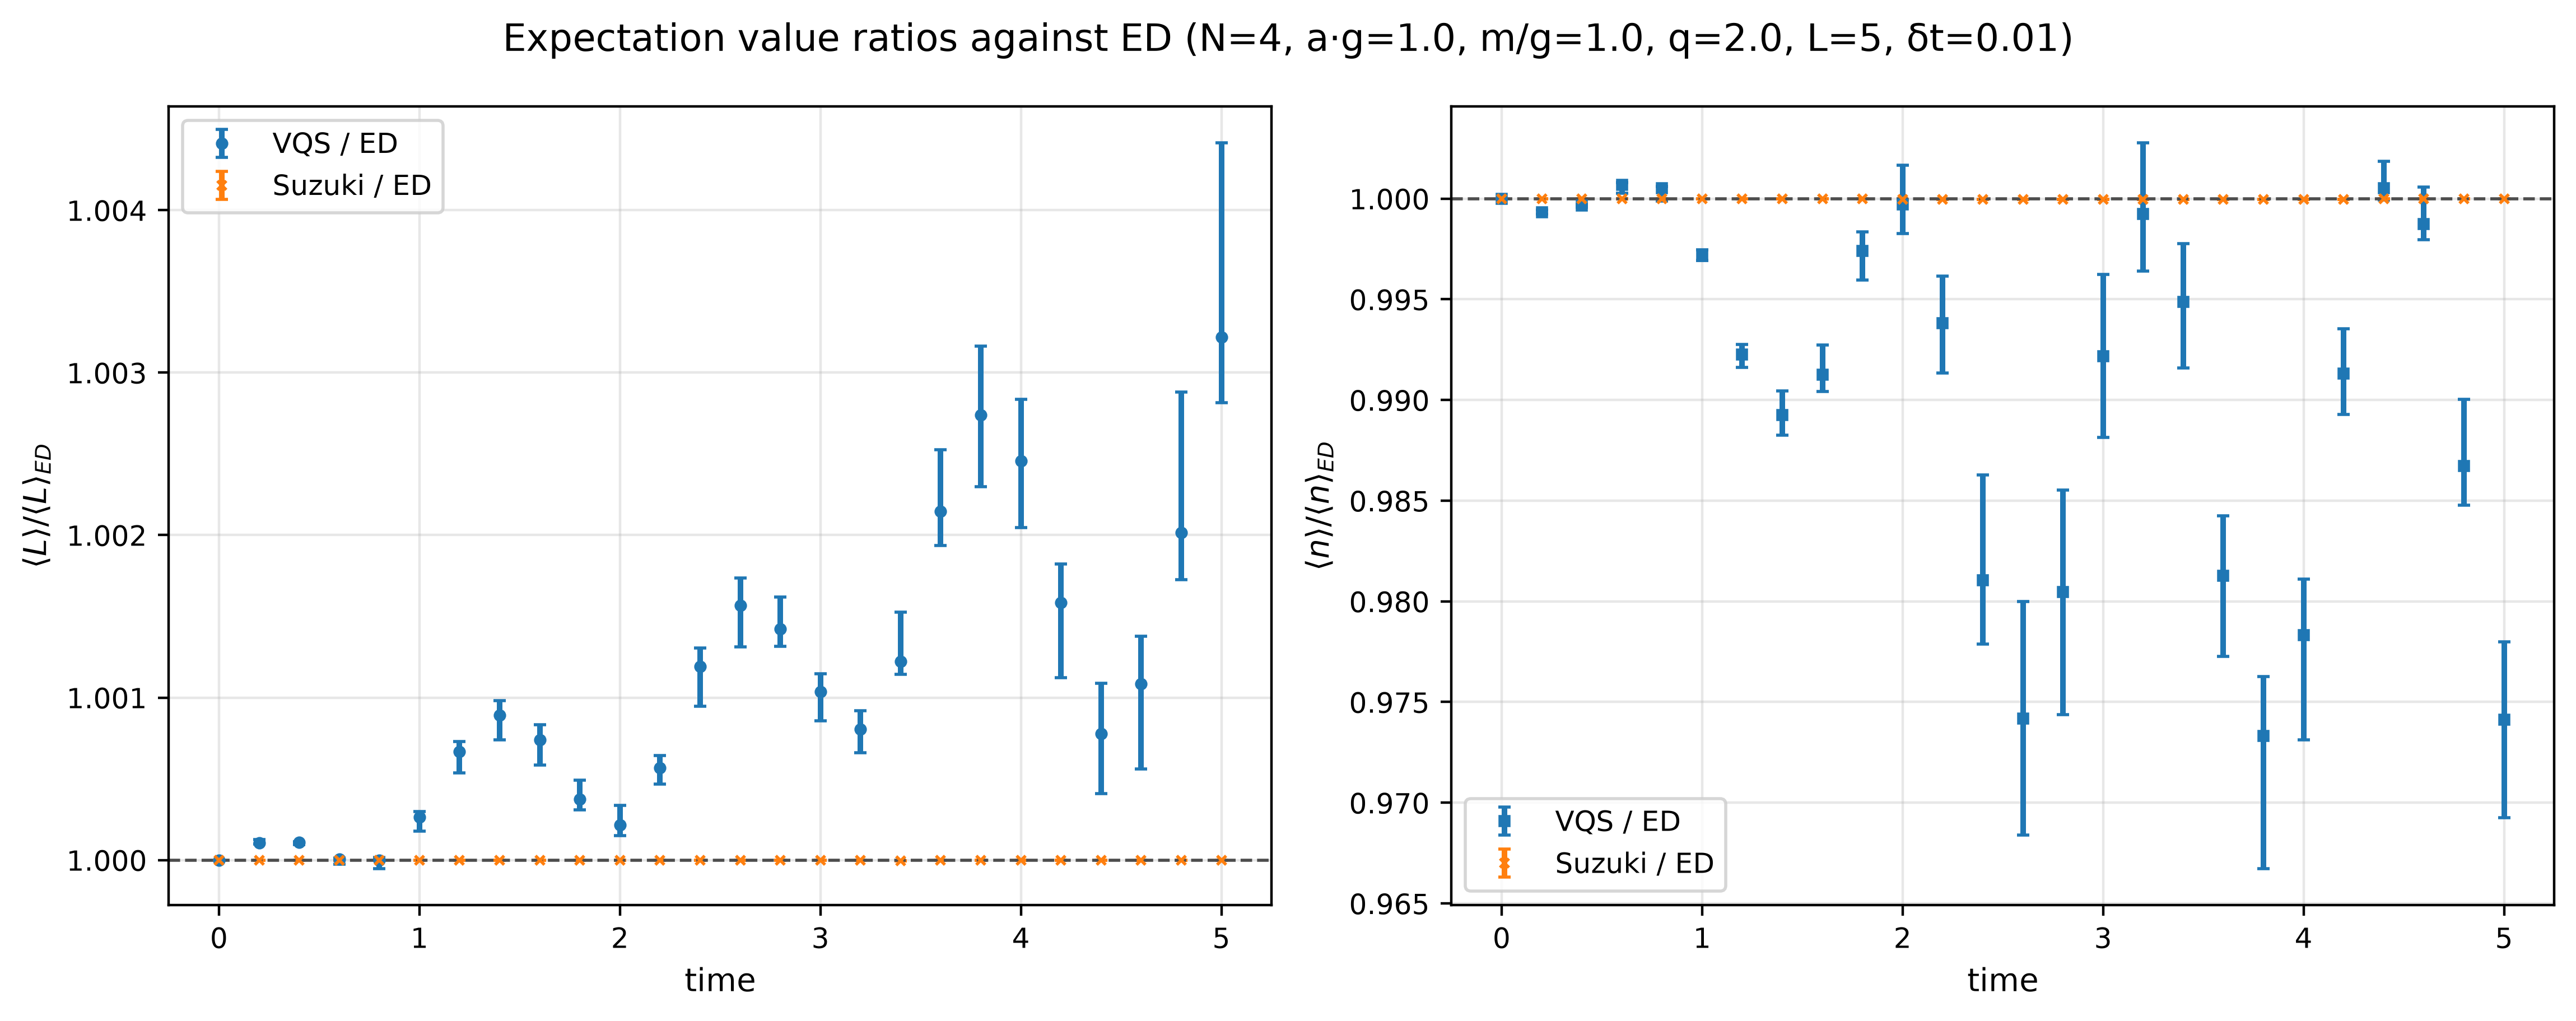

In [26]:
def plot_ratio_errorbars(ax, times, values, label, marker="o"):
    p25, median, p75 = module4_percentiles(values)
    stride = max(1, len(times) // MODULE4_ERRORBAR_POINTS)
    idx = onp.arange(0, len(times), stride)
    lower = median[idx] - p25[idx]
    upper = p75[idx] - median[idx]
    ax.errorbar(times[idx], median[idx], yerr=[lower, upper], fmt=marker, ms=3, capsize=2, label=label)


if module4_arrays is None:
    print("Expectation-value ratio plots skipped because Module 4 ensemble data is unavailable.")
else:
    times = module4_arrays["obs_times"]
    fig, axes = plt.subplots(1, 2, figsize=PLOT_TWO_PANEL_FIGSIZE)

    plot_ratio_errorbars(axes[0], times, module4_arrays["obs_ratio_vqs_electric_field"], "VQS / ED", marker="o")
    plot_ratio_errorbars(axes[0], times, module4_arrays["obs_ratio_suzuki_electric_field"], "Suzuki / ED", marker="x")
    axes[0].axhline(1.0, color="0.3", lw=1, ls="--")
    axes[0].set_xlabel("time")
    axes[0].set_ylabel(r"$\langle L\rangle / \langle L\rangle_{ED}$")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    plot_ratio_errorbars(axes[1], times, module4_arrays["obs_ratio_vqs_chiral_condensate"], "VQS / ED", marker="s")
    plot_ratio_errorbars(axes[1], times, module4_arrays["obs_ratio_suzuki_chiral_condensate"], "Suzuki / ED", marker="x")
    axes[1].axhline(1.0, color="0.3", lw=1, ls="--")
    axes[1].set_xlabel("time")
    axes[1].set_ylabel(r"$\langle n\rangle / \langle n\rangle_{ED}$")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.suptitle(
        "Expectation value ratios against ED "
        f"(N={PHYSICS_CONFIG['N']}, a·g={PHYSICS_CONFIG['ag']}, m/g={PHYSICS_CONFIG['m_over_g']}, "
        f"q={PHYSICS_CONFIG['q_final']}, L={MODULE4_FIXED_LAYER}, δt={MODULE4_FIXED_DT})"
    )
    fig.tight_layout()
    plt.show()